# Stage 2: Contextual Rule Classification

This notebook applies the validated contextual rules to buildings that remain unresolved after Stage 1. The rules use building geometry, address information, land-use context, nearby residential buildings, and validated polygon POIs to assign additional building classes.

**Input**
- Building data with Stage 1 classifications and basic geometric/address attributes.
- Cleaned land-use and POI contextual data.
- Contextual rules validated in the preceding rule-analysis notebooks.

**Output**
- Stage 2 building classifications and classification-source information.
- Updated building data containing both Stage 1 and Stage 2 results for subsequent feature engineering and machine learning.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import sys



ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

BUILDING_FILE = os.path.join(DATA_DIR, 'processed', 'germany_buildings_classified_stage1.parquet')
LANDUSE_FILE = os.path.join(DATA_DIR, 'processed', 'germany_landuse_mapped.parquet')
POI_FILE = os.path.join(DATA_DIR, 'processed', 'germany_pois_mapped.parquet')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)


In [2]:
print("Loading Germany building, Landuse and POI Data...")
gdf_bldg = gpd.read_parquet(BUILDING_FILE)
gdf_landuse = gpd.read_parquet(LANDUSE_FILE)
gdf_poi = gpd.read_parquet(POI_FILE)

print("Data loaded successfully!")

Loading Germany building, Landuse and POI Data...
Data loaded successfully!


In [3]:
# spatial join to assign building zones based on landuse polygons

# ── Make sure CRS matches ──
print(f"Buildings CRS : {gdf_bldg.crs.to_string()}")
print(f"Landuse CRS   : {gdf_landuse.crs.to_string()}")
print(f"POI CRS   : {gdf_poi.crs.to_string()}")

if gdf_bldg.crs != gdf_landuse.crs:
    gdf_landuse = gdf_landuse.to_crs(gdf_bldg.crs.to_string())
    print("Reprojected landuse to match buildings")
elif gdf_bldg.crs != gdf_poi.crs:
    gdf_poi = gdf_poi.to_crs(gdf_bldg.crs.to_string())
    print("Reprojected POI to match buildings")

Buildings CRS : EPSG:4326
Landuse CRS   : EPSG:4326
POI CRS   : EPSG:4326


In [4]:
# Initialise stage2 columns — only fill unclassified buildings
# stage2_l1 is None for everything at the start; rules fill it in
if 'stage2_l1' not in gdf_bldg.columns:
    gdf_bldg['stage2_l1']     = None
    gdf_bldg['stage2_l2']     = None
    gdf_bldg['stage2_source'] = None

# Convenience mask: buildings eligible for stage2 (not yet classified/filtered)
def unclassified_mask(gdf):
    """Returns boolean mask: True where stage1 didn't assign a real label."""
    return gdf['stage1_l1'].isna() & gdf['stage2_l1'].isna()

print(f"\n  Unclassified after stage1 : {unclassified_mask(gdf_bldg).sum():,}")


  Unclassified after stage1 : 25,530,280


In [5]:
# ──  Reporting helpers ────────────────────────────────────────────────

def _combined_l1(gdf):
    """
    Returns a Series: stage1_l1 if set, else stage2_l1.
    This is what we report on — the best label so far at any step.
    """
    return gdf['stage1_l1'].combine_first(gdf['stage2_l1'])


def distribution_report(gdf, step_name):
    """Prints a clean text summary of the COMBINED (stage1 + stage2) status."""
    l1 = _combined_l1(gdf)
    total      = len(gdf)
    filled     = (l1.notna() & (l1 != 'filter')).sum()
    filtered   = (l1 == 'filter').sum()
    empty      = l1.isna().sum()

    # L2 coverage
    classified_mask = l1.notna() & (l1 != 'filter')
    best_l2 = gdf['stage1_l2'].combine_first(gdf['stage2_l2'])
    l2_filled  = (classified_mask & best_l2.notna()).sum()
    l2_missing = (classified_mask & best_l2.isna()).sum()
    l2_fill_pct    = l2_filled  / filled * 100 if filled > 0 else 0
    l2_missing_pct = l2_missing / filled * 100 if filled > 0 else 0

    # How many were added by stage2 specifically
    stage2_added = (
        gdf['stage1_l1'].isna() &
        gdf['stage2_l1'].notna() &
        (gdf['stage2_l1'] != 'filter')
    ).sum()
    stage2_filtered = (
        gdf['stage1_l1'].isna() &
        (gdf['stage2_l1'] == 'filter')
    ).sum()

    print(f"\n{'='*55}")
    print(f"  {step_name}")
    print(f"{'='*55}")
    print(f"  Total              : {total:>12,}")
    print(f"  Classified         : {filled:>12,}  ({filled/total*100:.1f}%)")
    print(f"    └ with L2        : {l2_filled:>12,}  ({l2_fill_pct:.1f}% of classified)")
    print(f"    └ no L2          : {l2_missing:>12,}  ({l2_missing_pct:.1f}% of classified)")
    print(f"  Filtered           : {filtered:>12,}  ({filtered/total*100:.1f}%)")
    print(f"  Unclassified       : {empty:>12,}  ({empty/total*100:.1f}%)")
    print(f"\n  ── Stage 2 contribution ──")
    print(f"  Added by stage2    : {stage2_added:>12,}")
    print(f"  Filtered by stage2 : {stage2_filtered:>12,}")
    print(f"\n  L1 breakdown (combined):")
    print(l1.value_counts(dropna=False).to_string())
    print(f"\n  L2 breakdown (combined):")
    print(best_l2.value_counts(dropna=False).to_string())

    if gdf['stage2_source'].notna().any():
        print(f"\n  Stage2 source breakdown:")
        print(gdf['stage2_source'].value_counts(dropna=False).to_string())


def plot_distribution(gdf, step_name):
    """Two-panel dashboard: donut (overall status) + bar (L1 breakdown)."""
    l1    = _combined_l1(gdf)
    total = len(gdf)
    filled   = (l1.notna() & (l1 != 'filter')).sum()
    filtered = (l1 == 'filter').sum()
    empty    = l1.isna().sum()

    fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=150,
                             gridspec_kw={'width_ratios': [1, 2]})
    fig.suptitle(f"Classification Distribution: {step_name}", fontsize=22, fontweight='bold')

    # Donut
    labels_d = ['Classified', 'Filtered', 'Unclassified']
    sizes_d  = [filled, filtered, empty]
    colors_d = ['#2ca02c', '#d62728', '#7f7f7f']
    valid    = [(l, s, c) for l, s, c in zip(labels_d, sizes_d, colors_d) if s > 0]
    if valid:
        lv, sv, cv = zip(*valid)
        axes[0].pie(sv, labels=lv, colors=cv, autopct='%1.1f%%', startangle=90,
                    wedgeprops=dict(width=0.4, edgecolor='w'), textprops={'fontsize': 14})
        axes[0].set_title("Overall Status", fontsize=18)

    # Horizontal bar — classified L1 only
    classified_only = l1[l1.notna() & (l1 != 'filter')]
    if not classified_only.empty:
        l1_counts = classified_only.value_counts()
        total_cls = l1_counts.sum()
        max_val   = l1_counts.max()

        PALETTE = {
            'residential': '#1f77b4', 'commercial': '#ff7f0e',
            'agricultural': '#2ca02c', 'industrial': '#d62728',
            'civic': '#9467bd', 'semi_commercial': '#8c564b',
            'transportation': '#bcbd22', 'military': '#7f7f7f',
        }
        bar_colors = [PALETTE.get(c, '#aec7e8') for c in l1_counts.index]

        axes[1].barh(l1_counts.index, l1_counts.values, color=bar_colors)
        axes[1].set_title("Classified Building Types (L1)", fontsize=18)
        axes[1].set_xlabel("Number of Buildings", fontsize=14)
        axes[1].tick_params(labelsize=13)
        axes[1].xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k')
        )
        axes[1].set_xlim(0, max_val * 1.28)
        for i, (v, lbl) in enumerate(zip(l1_counts.values, l1_counts.index)):
            pct = v / total_cls * 100
            axes[1].text(v + max_val * 0.01, i, f"{v:,} ({pct:.1f}%)", va='center', fontsize=11)
    else:
        axes[1].text(0.5, 0.5, "No Classified Buildings Yet",
                     ha='center', va='center', fontsize=18)
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()


def plot_l2_fill_rate(gdf, step_name):
    l1      = _combined_l1(gdf)
    best_l2 = gdf['stage1_l2'].combine_first(gdf['stage2_l2'])

    classified = pd.DataFrame({'l1': l1, 'l2': best_l2})
    classified = classified[classified['l1'].notna() & (classified['l1'] != 'filter')].copy()

    if classified.empty:
        print(f"[plot_l2_fill_rate] No classified data yet at: {step_name}")
        return

    classified['has_l2'] = classified['l2'].notna()
    summary = classified.groupby(['l1', 'has_l2']).size().unstack(fill_value=0)
    summary.columns = [str(c) for c in summary.columns]
    rename_map = {'False': 'No L2', 'True': 'Has L2', False: 'No L2', True: 'Has L2'}
    summary = summary.rename(columns=rename_map)
    for col in ['No L2', 'Has L2']:
        if col not in summary.columns:
            summary[col] = 0
    raw_counts  = summary[['No L2', 'Has L2']].copy()
    summary_pct = raw_counts.div(raw_counts.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(16, 6), dpi=150)
    summary_pct.plot(kind='barh', stacked=True,
                     color=['#d62728', '#2ca02c'], edgecolor='white', ax=ax)

    for i, cat in enumerate(summary_pct.index):
        no_l2_pct  = summary_pct.loc[cat, 'No L2']
        has_l2_pct = summary_pct.loc[cat, 'Has L2']
        no_l2_n    = int(raw_counts.loc[cat, 'No L2'])
        has_l2_n   = int(raw_counts.loc[cat, 'Has L2'])
        if no_l2_pct > 0.08:
            ax.text(no_l2_pct / 2, i, f"{no_l2_n:,}\n({no_l2_pct*100:.1f}%)",
                    ha='center', va='center', fontsize=10, color='white', fontweight='bold')
        if has_l2_pct > 0.08:
            ax.text(no_l2_pct + has_l2_pct / 2, i, f"{has_l2_n:,}\n({has_l2_pct*100:.1f}%)",
                    ha='center', va='center', fontsize=11, color='white', fontweight='bold')

    ax.set_title(f'L2 Fill Rate per L1 — {step_name}', fontsize=15)
    ax.set_xlabel('Proportion of Buildings', fontsize=13)
    ax.set_ylabel('')
    ax.legend(['Missing L2', 'Has L2'], fontsize=11)
    ax.tick_params(labelsize=13)
    plt.tight_layout()
    plt.show()


def rule_precision_report(gdf, rule_mask, label, assigned_l1,
                          exclude_filtered=True, skip=False):
    """
    Validates a rule BEFORE applying it, using stage1 ground truth.

    rule_mask       : boolean Series — buildings the rule WOULD fire on
    label           : str description of the rule
    assigned_l1     : the l1 value the rule assigns ('filter', 'residential', etc.)
    exclude_filtered: if True (default), excludes stage1_l1 == 'filter' buildings
                      from the evaluation — since rule_mask already uses
                      unclassified_mask(), filtered buildings would never actually
                      be reached, so including them inflates false positive counts.
                      Set to False only when evaluating filter rules themselves
                      (Rules 1 and 2) where 'filter' IS the correct answer.
    skip            : if True, skips evaluation entirely and just prints a note.
                      Useful for rules where ground truth comparison isn't meaningful
                      (e.g. semi_commercial, which stage1 never assigns directly).
    """
    if skip:
        print(f"\n{'─'*50}")
        print(f"  Rule: {label}")
        print(f"{'─'*50}")
        print(f"  [Precision check skipped — no comparable stage1 ground truth]")
        print()
        return

    # Base: buildings with stage1 ground truth
    tagged_mask = gdf['stage1_l1'].notna()

    # Optionally exclude filter buildings from evaluation
    if exclude_filtered:
        tagged_mask = tagged_mask & (gdf['stage1_l1'] != 'filter')

    tagged = gdf[tagged_mask].copy()
    fired  = tagged[rule_mask.reindex(tagged.index, fill_value=False)]

    total_fired = len(fired)
    if total_fired == 0:
        print(f"\n  [{label}] Rule fires on 0 tagged buildings — cannot evaluate")
        return

    correct   = (fired['stage1_l1'] == assigned_l1).sum()
    fp        = total_fired - correct
    precision = correct / total_fired

    note = "" if not exclude_filtered else "  (filter buildings excluded from eval)"

    print(f"\n{'─'*50}")
    print(f"  Rule: {label}{note}")
    print(f"{'─'*50}")
    print(f"  Fires on tagged buildings : {total_fired:,}")
    print(f"  Correct (precision)       : {correct:,}  ({precision:.1%})")
    print(f"  False positives           : {fp:,}  ({fp/total_fired:.1%})")
    if fp > 0:
        print(f"\n  FP breakdown (what stage1 says):")
        print(
            fired[fired['stage1_l1'] != assigned_l1]['stage1_l1']
            .value_counts().head(8).to_string()
        )
    print()


def evaluate_step(gdf, step_name):
    """Master wrapper: text report + two charts."""
    distribution_report(gdf, step_name)
    plot_distribution(gdf, step_name)
    plot_l2_fill_rate(gdf, step_name)




  Baseline — after Stage 1
  Total              :   38,802,372
  Classified         :    9,150,848  (23.6%)
    └ with L2        :    4,487,423  (49.0% of classified)
    └ no L2          :    4,663,425  (51.0% of classified)
  Filtered           :    4,121,244  (10.6%)
  Unclassified       :   25,530,280  (65.8%)

  ── Stage 2 contribution ──
  Added by stage2    :            0
  Filtered by stage2 :            0

  L1 breakdown (combined):
stage1_l1
None               25530280
residential         7765260
filter              4121244
commercial           424475
agricultural         313609
civic                311495
industrial           301728
transportation        22301
military               8288
semi_commercial        3692

  L2 breakdown (combined):
stage1_l2
None                         34314919
SFH                           1648916
MFH                           1470564
TH                             326675
farm_auxiliary                 241815
retail                         1452

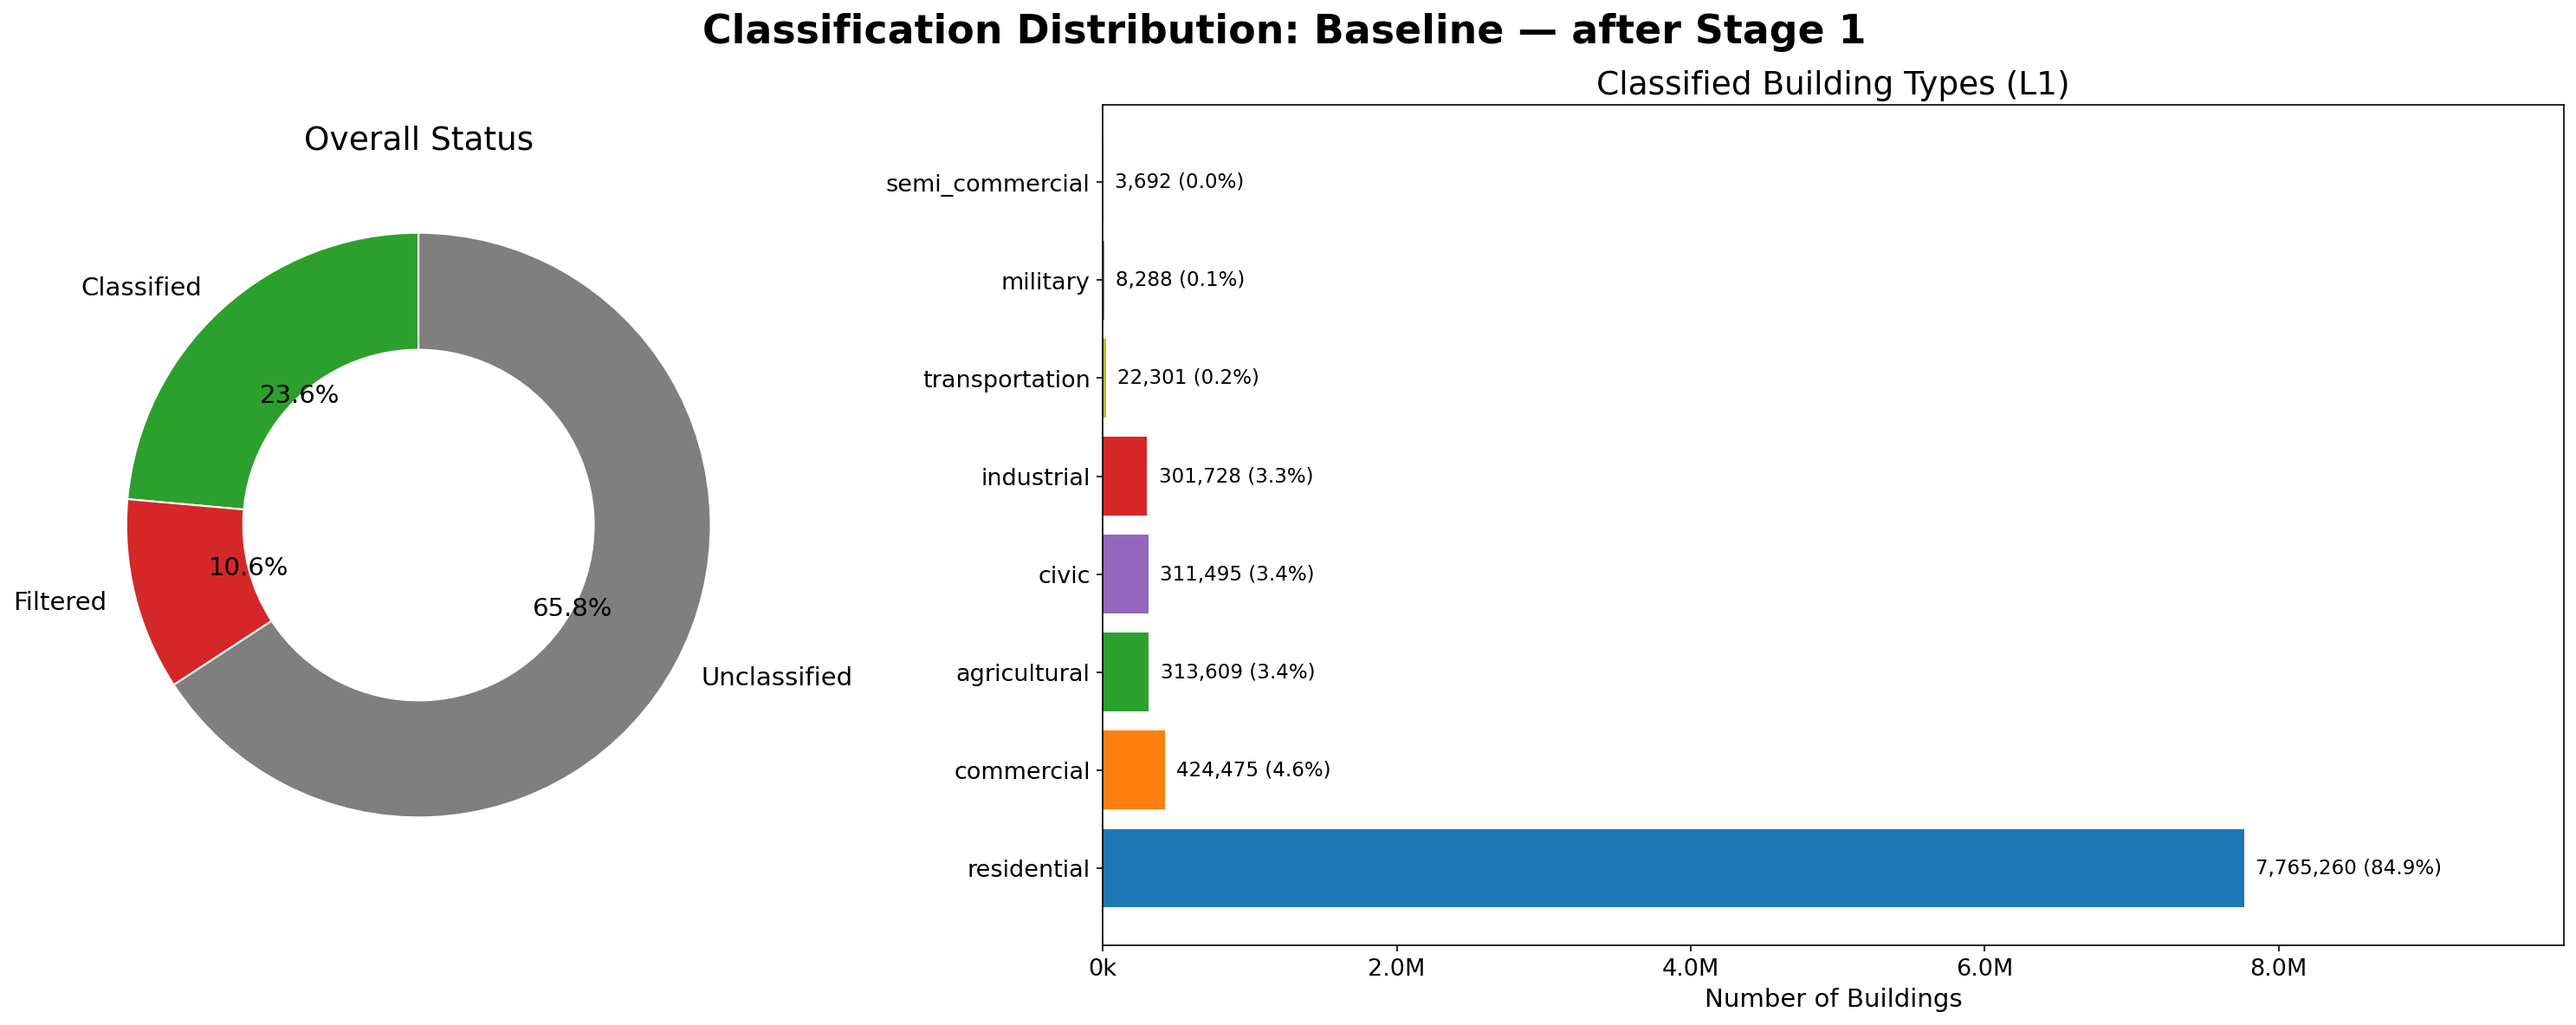

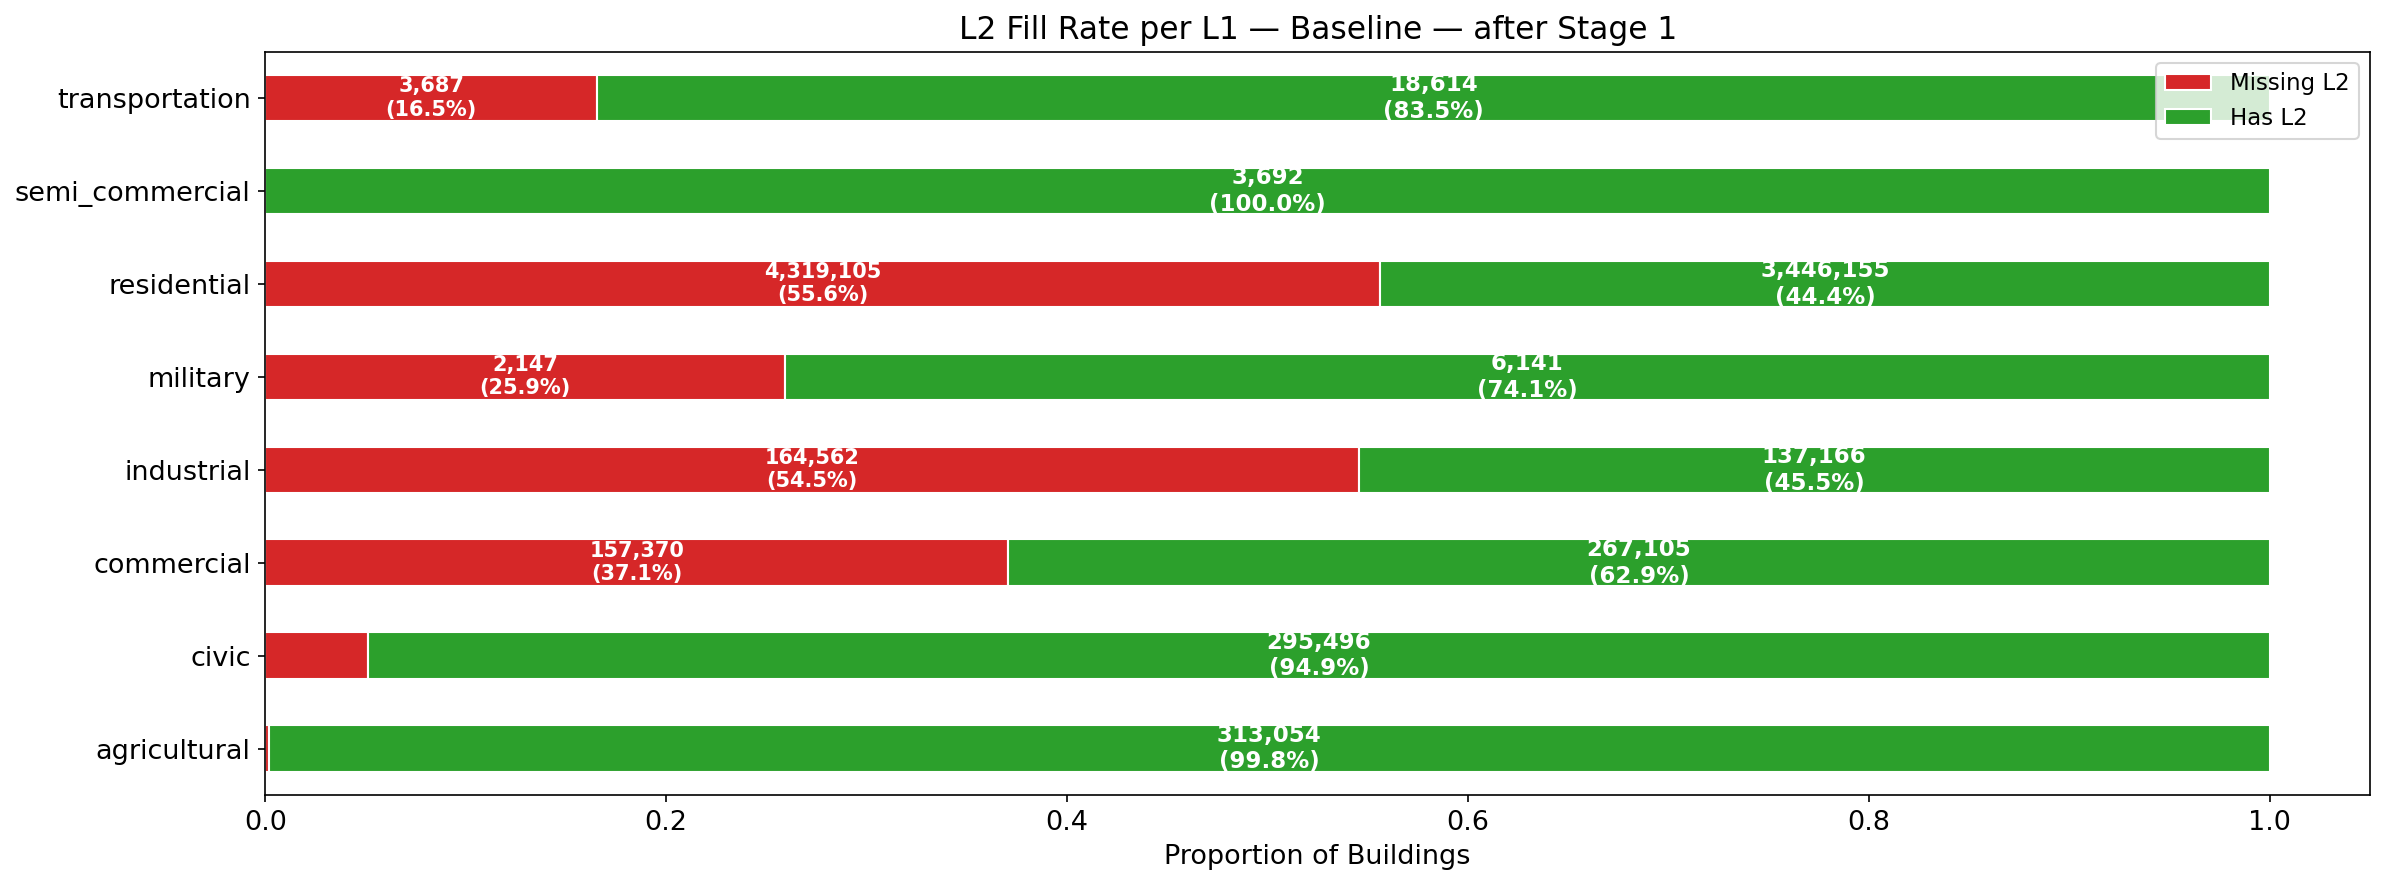

In [6]:
evaluate_step(gdf_bldg, "Baseline — after Stage 1")

### Data Assembly - Join landuse and POI data to Building data

In [7]:
print(f"Landuse polygons (mapped): {len(gdf_landuse):,}")

if 'zone_l1' not in gdf_bldg.columns:
    print("Running landuse spatial join (building centroid within landuse zone)...")
    if gdf_bldg.crs != gdf_landuse.crs:
        gdf_landuse = gdf_landuse.to_crs(gdf_bldg.crs)

    print("Computing centroids (via projected CRS)...")
    bldg_centroids = gdf_bldg[['id', 'geometry']].copy()

    # Project to a flat map (3035), find the true center, project back to GPS (4326)
    bldg_centroids['geometry'] = gdf_bldg['geometry'].to_crs("EPSG:3035").centroid.to_crs(gdf_bldg.crs)

    joined = gpd.sjoin(
        bldg_centroids,
        gdf_landuse[['id', 'geometry', 'zone_l1', 'zone_l2', 'landuse', 'zone_area_sqm']],
        how='left', predicate='within',
        lsuffix='bldg', rsuffix='zone'
    )

    # Handle buildings in multiple overlapping zones:
    # smallest zone + priority (industrial > commercial > residential) wins
    priority_map = {'industrial': 1, 'retail': 2, 'commercial': 3,
                    'military': 2, 'residential': 4,}
    joined['_priority'] = joined['landuse'].map(priority_map).fillna(9)
    joined = joined.sort_values(
        ['id_bldg', 'zone_area_sqm', '_priority'], ascending=[True, True, True]
    )
    joined_clean = joined[~joined.index.duplicated(keep='first')].copy()

    # Semi-commercial: buildings that touch BOTH residential AND commercial zones
    res_ids  = set(joined[joined['zone_l1'] == 'residential']['id_bldg'])
    com_ids  = set(joined[joined['zone_l1'] == 'commercial']['id_bldg'])
    semi_ids = res_ids & com_ids

    gdf_bldg['landuse_l1']        = joined_clean.set_index('id_bldg')['zone_l1'].reindex(gdf_bldg['id'].values).values
    gdf_bldg['landuse_l2']        = joined_clean.set_index('id_bldg')['zone_l2'].reindex(gdf_bldg['id'].values).values
    gdf_bldg['landuse_used']   = joined_clean.set_index('id_bldg')['landuse'].reindex(gdf_bldg['id'].values).values
    gdf_bldg['landuse_osm_id'] = joined_clean.set_index('id_bldg')['id_zone'].reindex(gdf_bldg['id'].values).values

    # Apply semi_commercial to zone_l1 where appropriate
    gdf_bldg.loc[gdf_bldg['id'].isin(semi_ids), 'landuse_l1'] = 'semi_commercial'
    gdf_bldg.loc[gdf_bldg['id'].isin(semi_ids), 'landuse_used'] = 'residential_commercial'

    print(f"  Buildings in a mapped zone : {gdf_bldg['landuse_l1'].notna().sum():,}")
    print(f"  Buildings outside any zone : {gdf_bldg['landuse_l1'].isna().sum():,}")
    print(gdf_bldg['landuse_l1'].value_counts(dropna=False).to_string())
else:
    print("Landuse already attached, skipping spatial join.")

Landuse polygons (mapped): 3,294,732
Running landuse spatial join (building centroid within landuse zone)...
Computing centroids (via projected CRS)...
  Buildings in a mapped zone : 30,203,825
  Buildings outside any zone : 8,598,547
landuse_l1
residential        27036162
NaN                 8598547
agricultural        1751210
commercial           703846
industrial           660189
military              30794
semi_commercial       21624


In [8]:
def get_trusted_zones(gdf, zone_type, threshold=0.90, min_buildings=3):
    """
    Returns a set of landuse_osm_id values that are 'trustworthy' enough
    to classify untagged buildings inside them.

    A zone is trusted if:
      - At least min_buildings stage1-classified buildings are inside it
      - At least threshold% of those buildings agree with zone_type
    """
    # Only use stage1 ground truth
    zone_bldgs = gdf[
        gdf['stage1_l1'].notna() &
        (gdf['stage1_l1'] != 'filter') &
        (gdf['landuse_l1'] == zone_type) &
        gdf['landuse_osm_id'].notna()
    ].copy()

    per_polygon = zone_bldgs.groupby('landuse_osm_id')['stage1_l1'].agg(
        n_buildings='count',
        n_matching=lambda x: (x == zone_type).sum()
    ).reset_index()

    per_polygon['agreement_rate'] = per_polygon['n_matching'] / per_polygon['n_buildings']

    trusted  = per_polygon[
        (per_polygon['n_buildings'] >= min_buildings) &
        (per_polygon['agreement_rate'] >= threshold)
    ]
    trusted_ids    = set(trusted['landuse_osm_id'])

    print(f"\n{zone_type.upper()} trusted zones:")
    print(f"  Trusted (>= {min_buildings} bldgs & >= {threshold:.0%} pure) : {len(trusted):,}")
    print(f"  Untrusted (excluded)                                : {len(per_polygon) - len(trusted):,}")
    
    return trusted_ids

trusted_residential = get_trusted_zones(gdf_bldg, 'residential', 0.90, 5)
trusted_commercial  = get_trusted_zones(gdf_bldg, 'commercial',  0.90, 3)
trusted_industrial  = get_trusted_zones(gdf_bldg, 'industrial',  0.90, 3)
trusted_military    = get_trusted_zones(gdf_bldg, 'military',    0.90, 1)



RESIDENTIAL trusted zones:
  Trusted (>= 5 bldgs & >= 90% pure) : 71,767
  Untrusted (excluded)                                : 149,584

COMMERCIAL trusted zones:
  Trusted (>= 3 bldgs & >= 90% pure) : 5,782
  Untrusted (excluded)                                : 43,071

INDUSTRIAL trusted zones:
  Trusted (>= 3 bldgs & >= 90% pure) : 5,639
  Untrusted (excluded)                                : 22,498

MILITARY trusted zones:
  Trusted (>= 1 bldgs & >= 90% pure) : 321
  Untrusted (excluded)                                : 307


In [9]:
print("Isolating Polygon POIs...")
polygon_pois = gdf_poi[gdf_poi.geom_type.isin(['Polygon','MultiPolygon'])].copy()
print(f"Polygon POIs : {len(polygon_pois):,}  (building outlines with POI tags)")

print(f"\nType breakdown")
print(polygon_pois['poi_l1'].value_counts())

polygon_pois = polygon_pois[[
    'id', 'geometry', 'poi_l1', 'poi_l2', 'poi_source', 'poi_used'
]].copy()

if polygon_pois.crs != gdf_bldg.crs:
    polygon_pois = polygon_pois.to_crs(gdf_bldg.crs)
    
print("Computing building centroids for Polygon POI join...")
bldg_centroids = gdf_bldg[['id', 'geometry']].copy()

bldg_centroids['geometry'] = bldg_centroids['geometry'].to_crs("EPSG:3035").centroid.to_crs(gdf_bldg.crs)
    
print("Running spatial join...")
spatial_match = gpd.sjoin(
    bldg_centroids,
    polygon_pois,
    how='inner',
    predicate='within',
    lsuffix='bldg',
    rsuffix='poi'
)

# Remove self-matches
spatial_match = spatial_match[spatial_match['id_bldg'] != spatial_match['id_poi']].copy()

print("Resolving overlaps using Priority Ladder...")
POI_L1_PRIORITY = {
    'civic': 1, 'industrial': 2, 'semi_commercial': 3, 
    'commercial': 4, 'residential': 5, 'transportation': 6
}

spatial_match['l1_priority'] = spatial_match['poi_l1'].map(POI_L1_PRIORITY).fillna(99)

spatial_resolved = (
    spatial_match
    .sort_values(['id_bldg', 'l1_priority'])
    .groupby('id_bldg')
    .first()
    .reset_index()
)

# Rename id_bldg to bldg_id
spatial_resolved = spatial_resolved.rename(columns={'id_bldg': 'bldg_id'})

target_columns = ['bldg_id', 'poi_l1', 'poi_l2', 'poi_source', 'poi_used']
poi_in_bldg = spatial_resolved[target_columns].copy()

print(f"Created final DataFrame with {len(poi_in_bldg):,} building-to-POI mappings.")


Isolating Polygon POIs...
Polygon POIs : 85,743  (building outlines with POI tags)

Type breakdown
poi_l1
civic              62045
commercial         20778
transportation      1921
agricultural         822
industrial           164
semi_commercial        7
residential            5
military               1
Name: count, dtype: int64
Computing building centroids for Polygon POI join...
Running spatial join...
Resolving overlaps using Priority Ladder...
Created final DataFrame with 244,686 building-to-POI mappings.


### Rule 1 – Filter Small Buildings without an address

In [10]:
R1_AREA_MAX    = 40     # m² — analysis justified this cutoff
R1_AREA_GARAGE = 50     # upper bound for possible garage band (Rule 2)

# Create a mask just for VALIDATION 
val_r1_mask = (
    (gdf_bldg['area_sqm'].between(0, R1_AREA_MAX)) &
    (gdf_bldg['address_tier'] == 0)      
)

# Validate 
rule_precision_report(gdf_bldg, val_r1_mask,
                      "Rule 1: area<40 + no address → filter",
                      "filter",
                      exclude_filtered=False)  


──────────────────────────────────────────────────
  Rule: Rule 1: area<40 + no address → filter
──────────────────────────────────────────────────
  Fires on tagged buildings : 2,889,391
  Correct (precision)       : 2,655,427  (91.9%)
  False positives           : 233,964  (8.1%)

  FP breakdown (what stage1 says):
stage1_l1
residential        96403
industrial         60158
agricultural       31293
commercial         28216
civic              13472
transportation      3767
military             651
semi_commercial        4



Rule 1 applied: 5,627,188 buildings → filter

  After Rule 1 — Small area filter
  Total              :   38,802,372
  Classified         :    9,150,848  (23.6%)
    └ with L2        :    4,487,423  (49.0% of classified)
    └ no L2          :    4,663,425  (51.0% of classified)
  Filtered           :    9,748,432  (25.1%)
  Unclassified       :   19,903,092  (51.3%)

  ── Stage 2 contribution ──
  Added by stage2    :            0
  Filtered by stage2 :    5,627,188

  L1 breakdown (combined):
stage1_l1
None               19903092
filter              9748432
residential         7765260
commercial           424475
agricultural         313609
civic                311495
industrial           301728
transportation        22301
military               8288
semi_commercial        3692

  L2 breakdown (combined):
stage1_l2
None                         34314919
SFH                           1648916
MFH                           1470564
TH                             326675
farm_auxiliary      

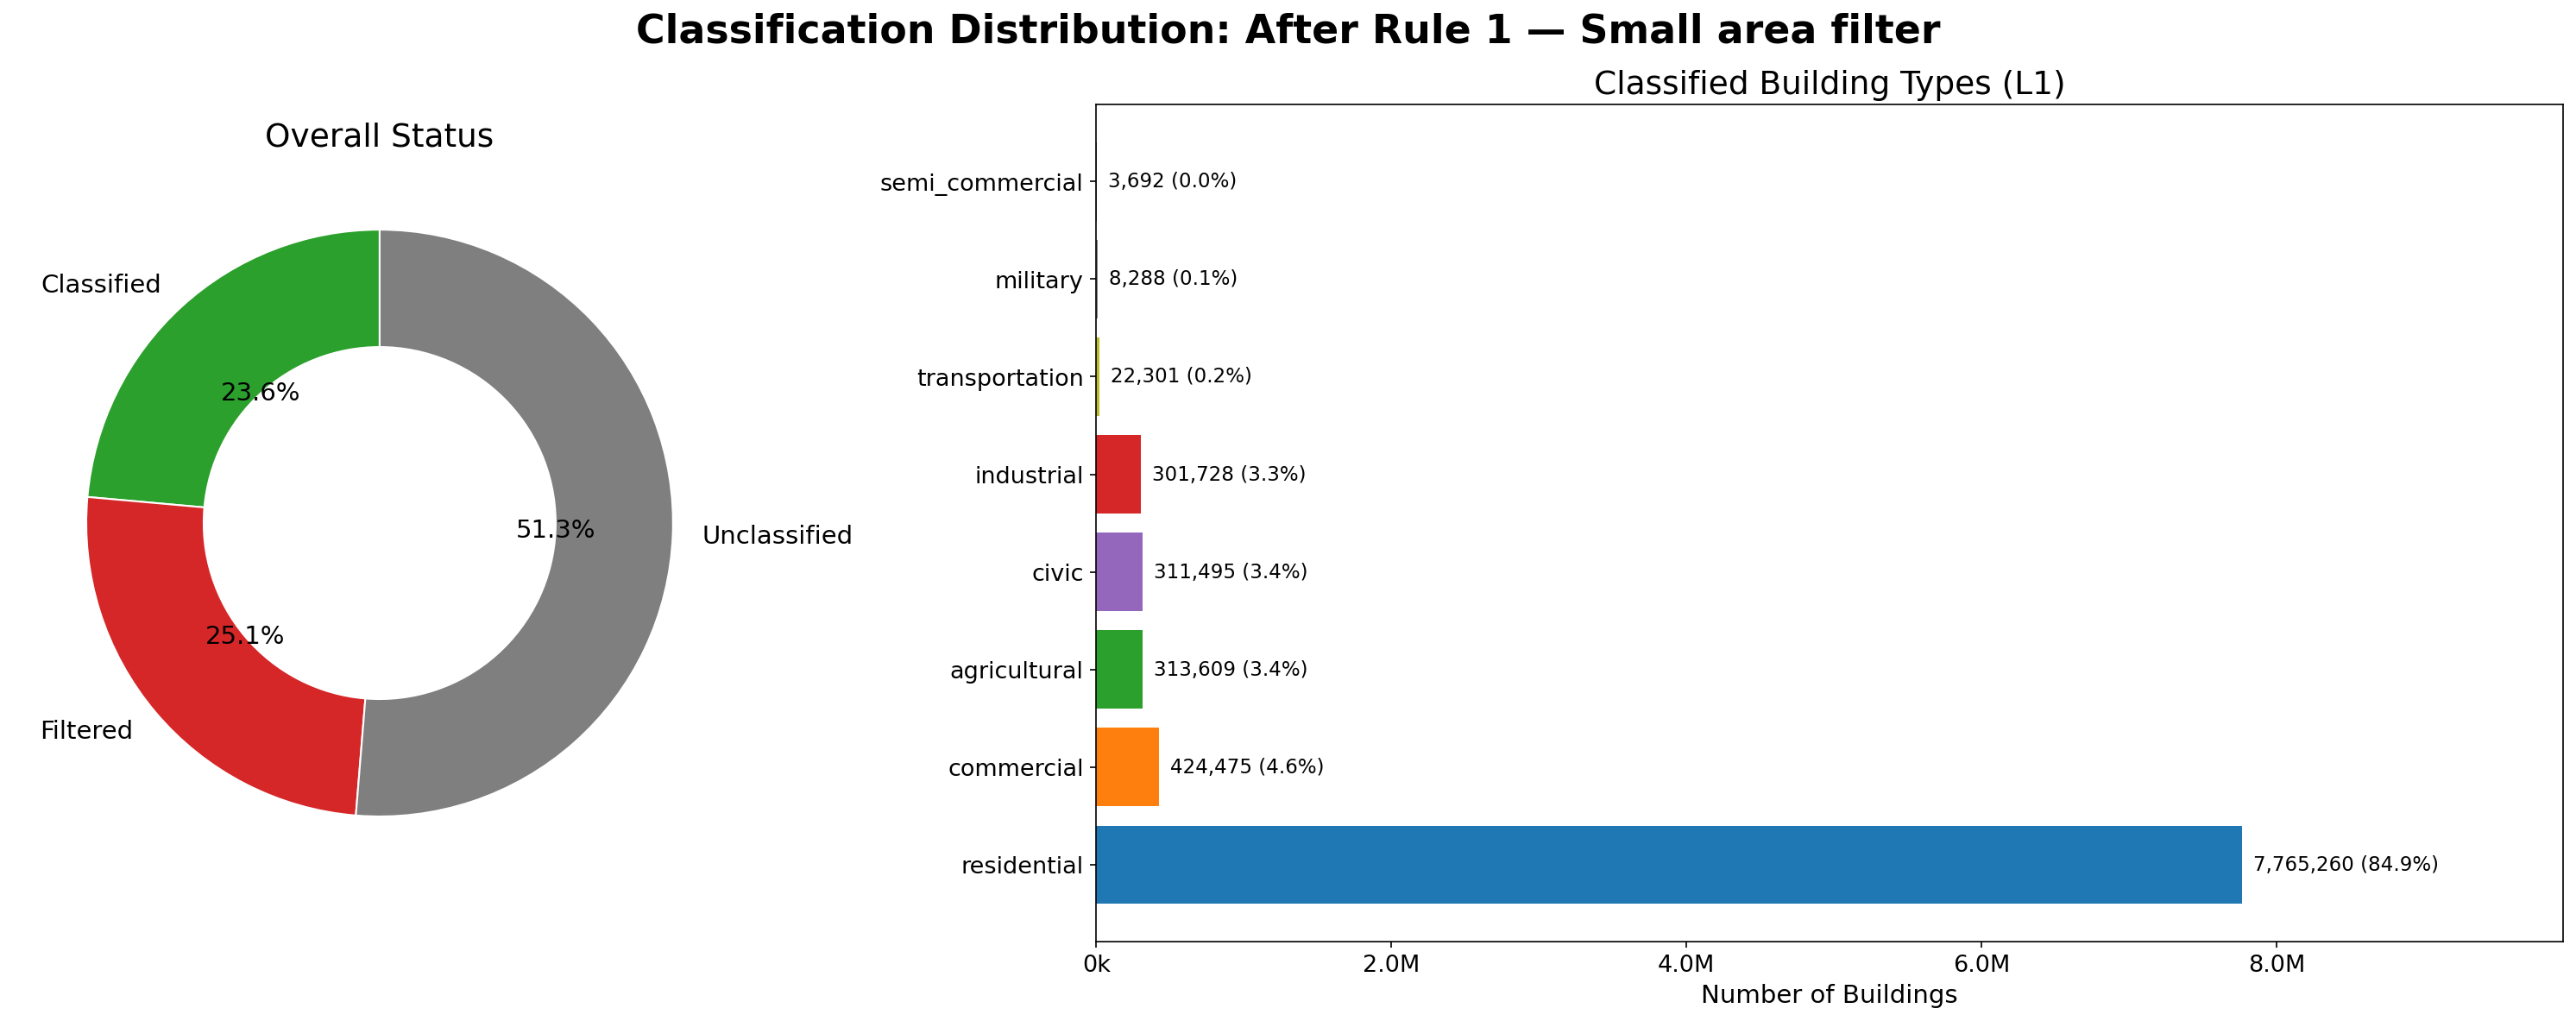

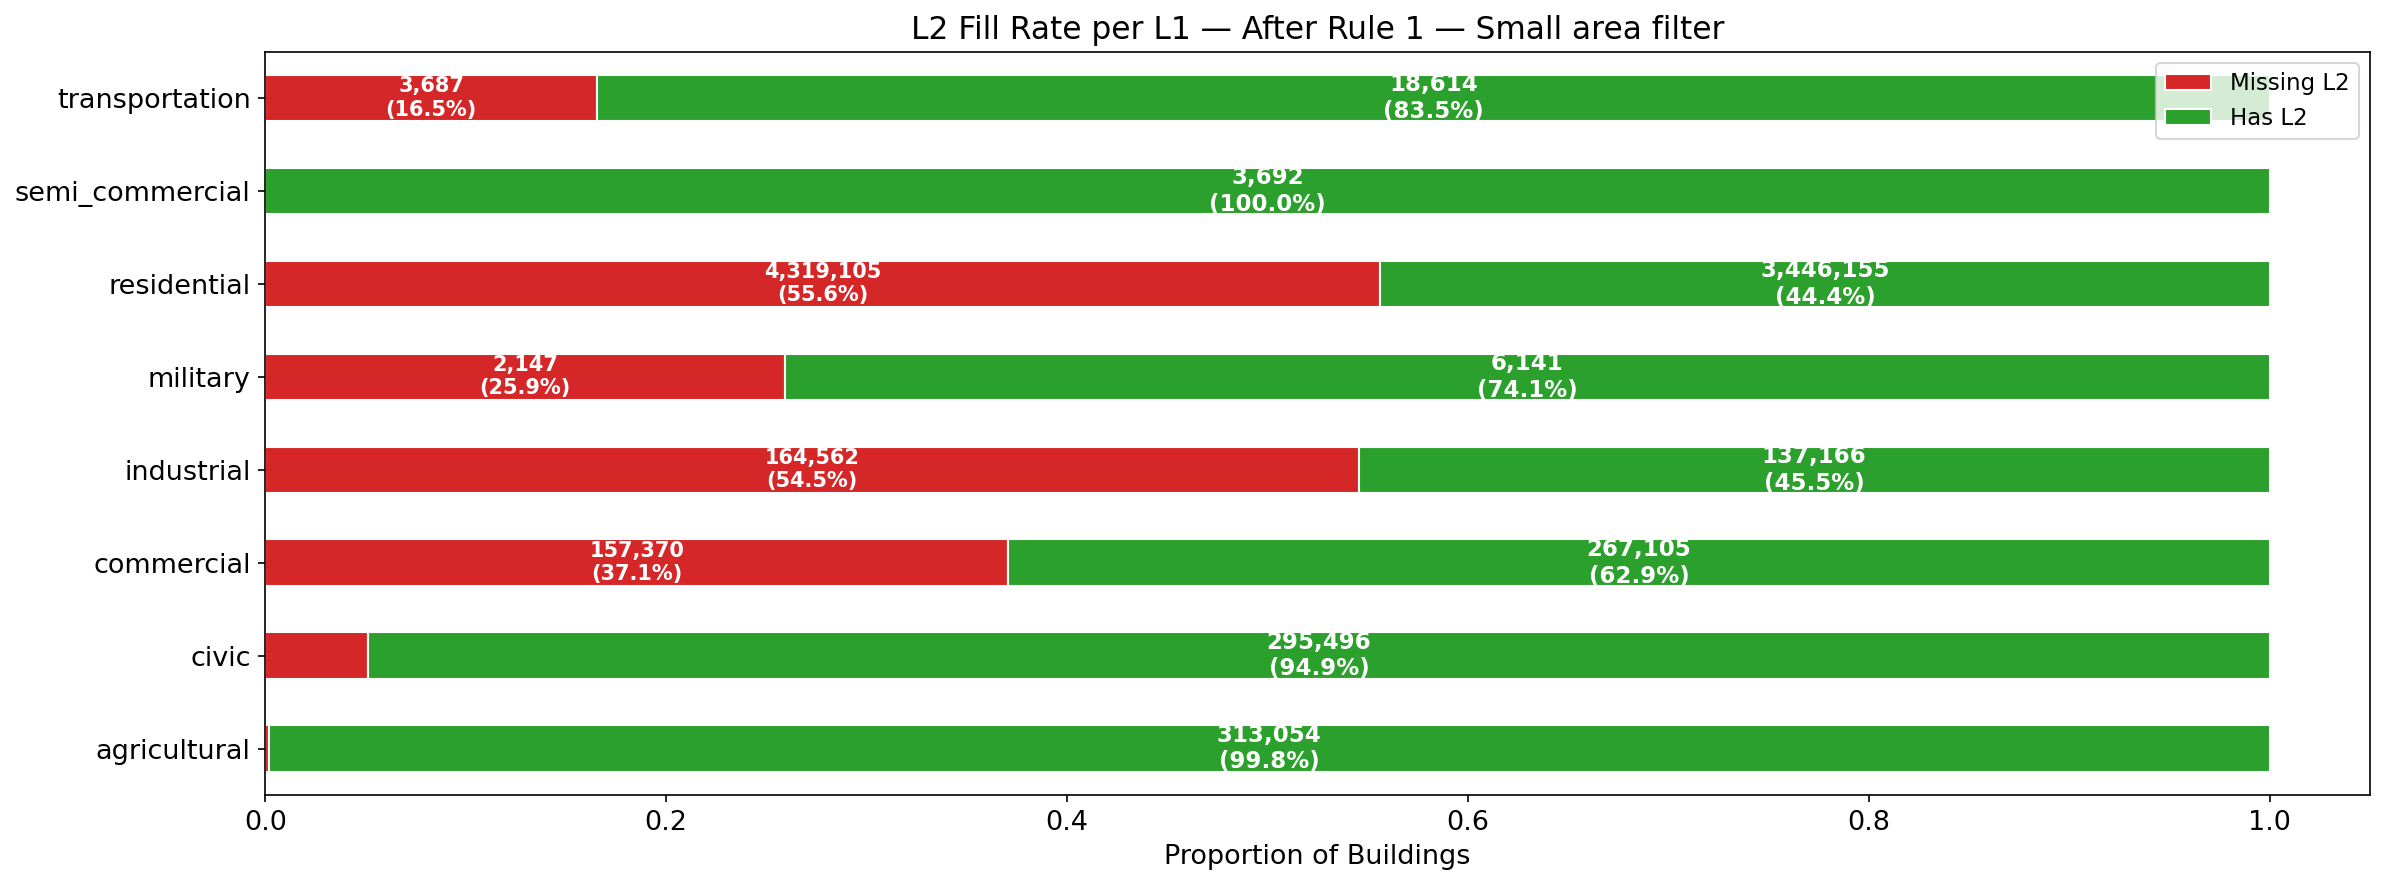

In [11]:
r1_mask = (
    unclassified_mask(gdf_bldg) & 
    val_r1_mask 
)

# Apply
gdf_bldg.loc[r1_mask, 'stage2_l1']     = 'filter'
gdf_bldg.loc[r1_mask, 'stage2_l2']     = None
gdf_bldg.loc[r1_mask, 'stage2_source'] = 'rule1_small_area'

print(f"Rule 1 applied: {r1_mask.sum():,} buildings → filter")
evaluate_step(gdf_bldg, "After Rule 1 — Small area filter")

### RULE 2 - Filter Small Unaddressed Buildings Near Addressed Residential Buildings (Garages)

In [12]:
# Only look at small, unaddressed buildings in residential zones
var_candidate_mask = (
    (gdf_bldg['area_sqm'].between(40, 50)) & 
    (gdf_bldg['address_tier'] == 0) & 
    gdf_bldg['landuse_osm_id'].isin(trusted_residential)
)
var_candidates = gdf_bldg[var_candidate_mask].to_crs(epsg=3035)

# Only look at houses with addresses
addressed_houses = gdf_bldg[
    (gdf_bldg['address_tier'] == 2) & 
    (gdf_bldg['stage1_l1'] == 'residential')
].to_crs(epsg=3035)

# Run the relational math (Accuracy optimization like Option B)
print(f"Running 5-meter adjacency check on {len(var_candidates):,} candidate buildings...")
joined_gar = gpd.sjoin_nearest(
    var_candidates[['geometry', 'id']],
    addressed_houses[['geometry', 'id']],
    how='left', 
    max_distance=5, 
    distance_col='dist_to_house',
    lsuffix='cand', 
    rsuffix='house'
)

# Resolve overlaps and apply the logic
# (If a candidate is near multiple houses, it appears multiple times. Drop duplicates.)
var_has_neighbor = joined_gar.dropna(subset=['id_house']).drop_duplicates(subset=['id_cand'])
var_garage_ids = var_has_neighbor['id_cand'].values

# Apply to your main DataFrame
val_r2_mask = gdf_bldg['id'].isin(var_garage_ids)
rule_precision_report(gdf_bldg, val_r2_mask,
                      "Rule 2: garage band in residential zone → filter",
                      "filter",
                      exclude_filtered=False)

Running 5-meter adjacency check on 499,622 candidate buildings...

──────────────────────────────────────────────────
  Rule: Rule 2: garage band in residential zone → filter
──────────────────────────────────────────────────
  Fires on tagged buildings : 95,782
  Correct (precision)       : 91,461  (95.5%)
  False positives           : 4,321  (4.5%)

  FP breakdown (what stage1 says):
stage1_l1
residential       3877
agricultural       203
commercial         116
industrial          86
civic               30
transportation       7
military             2



Running 5-meter adjacency check on 297,555 candidate buildings...
Rule 2 applied: 74,323 buildings → filter/garage

  After Rule 2 — Garage band filter
  Total              :   38,802,372
  Classified         :    9,150,848  (23.6%)
    └ with L2        :    4,487,423  (49.0% of classified)
    └ no L2          :    4,663,425  (51.0% of classified)
  Filtered           :    9,822,755  (25.3%)
  Unclassified       :   19,828,769  (51.1%)

  ── Stage 2 contribution ──
  Added by stage2    :            0
  Filtered by stage2 :    5,701,511

  L1 breakdown (combined):
stage1_l1
None               19828769
filter              9822755
residential         7765260
commercial           424475
agricultural         313609
civic                311495
industrial           301728
transportation        22301
military               8288
semi_commercial        3692

  L2 breakdown (combined):
stage1_l2
None                         34314919
SFH                           1648916
MFH                      

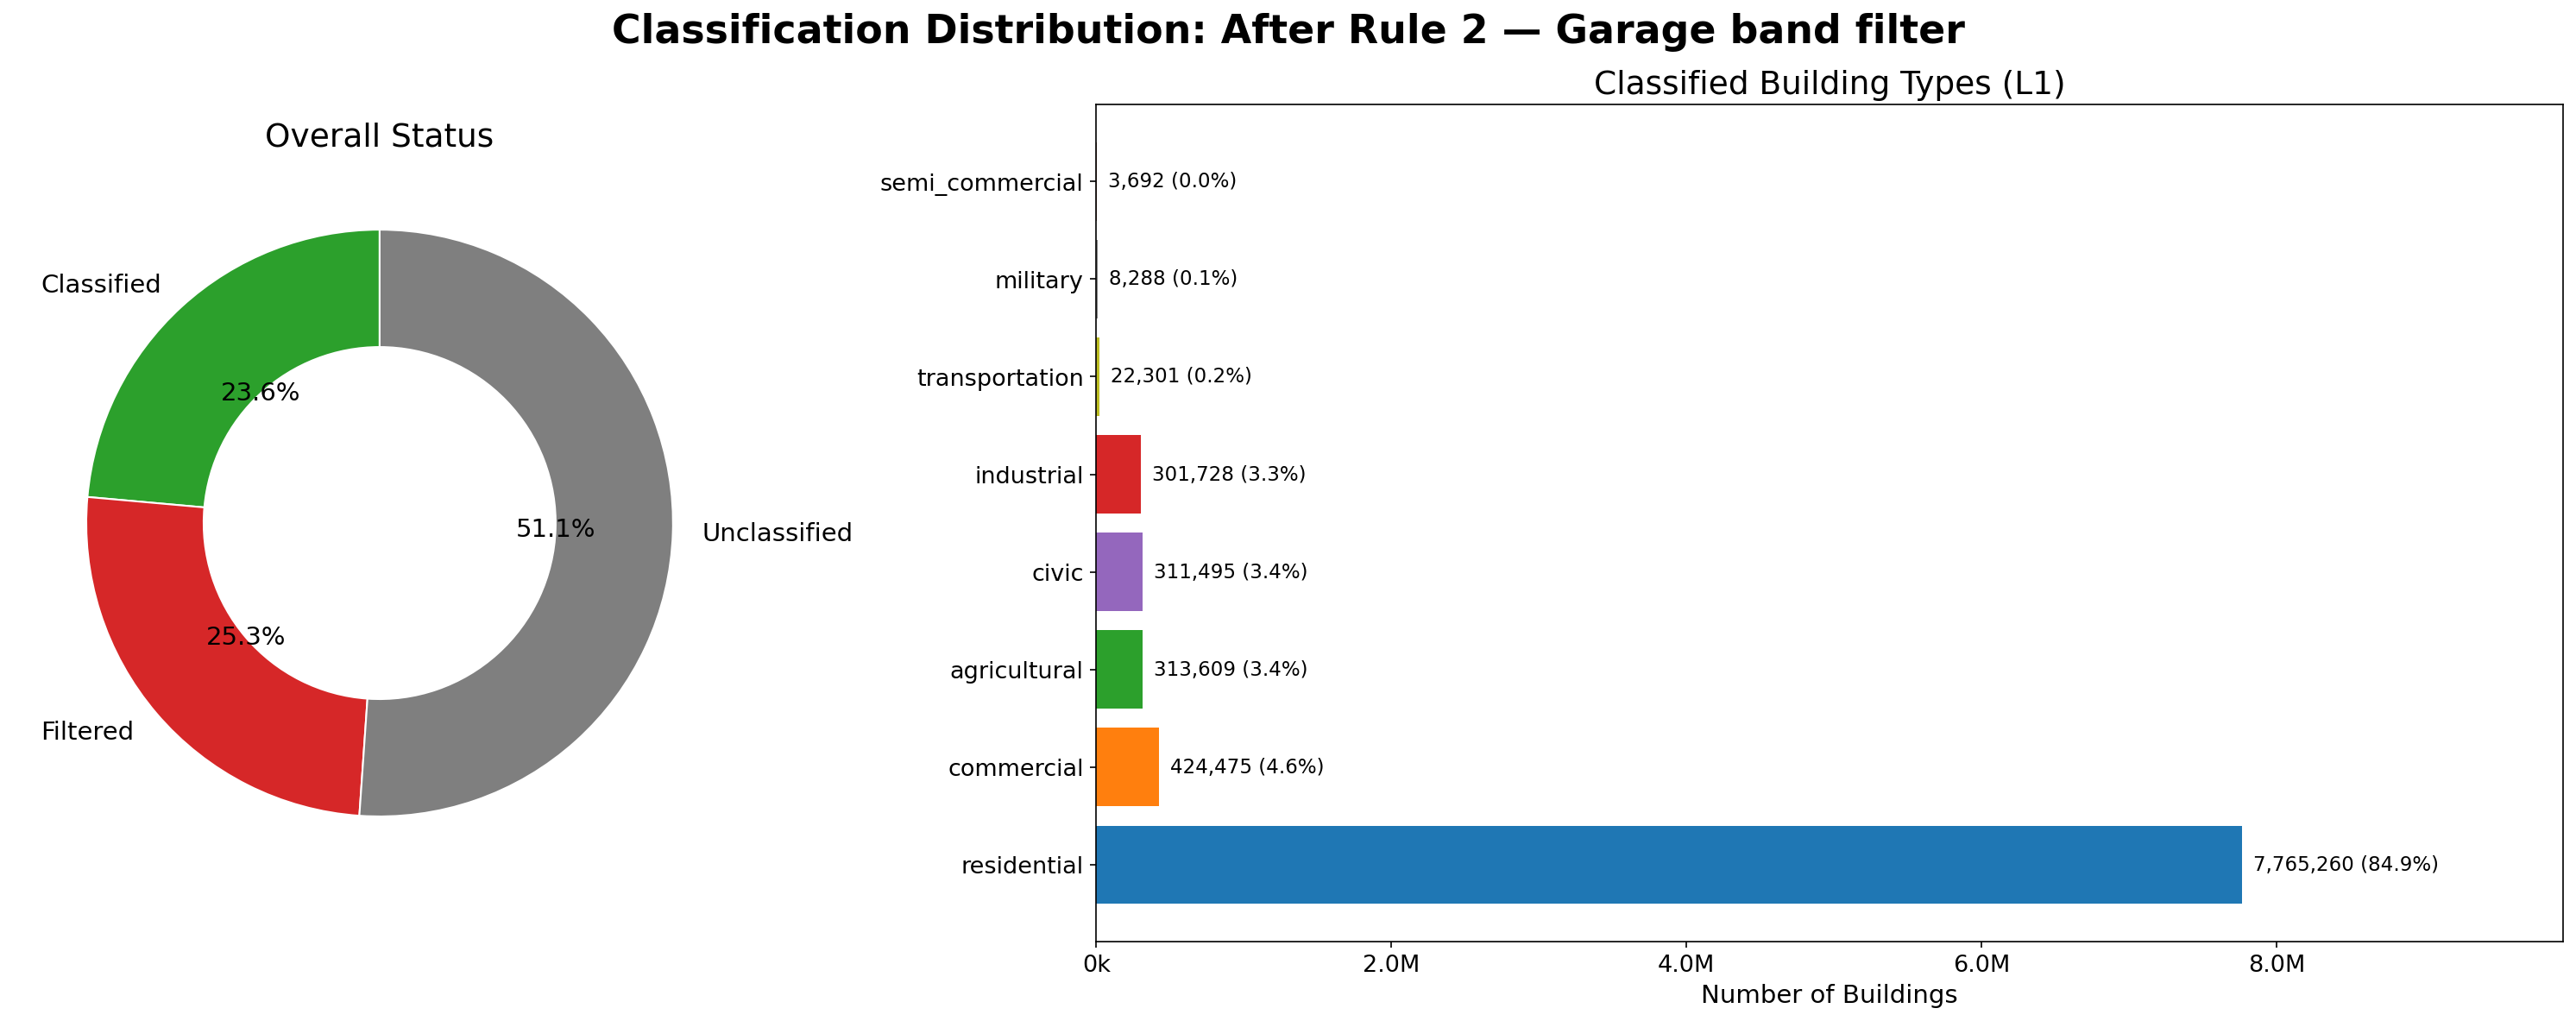

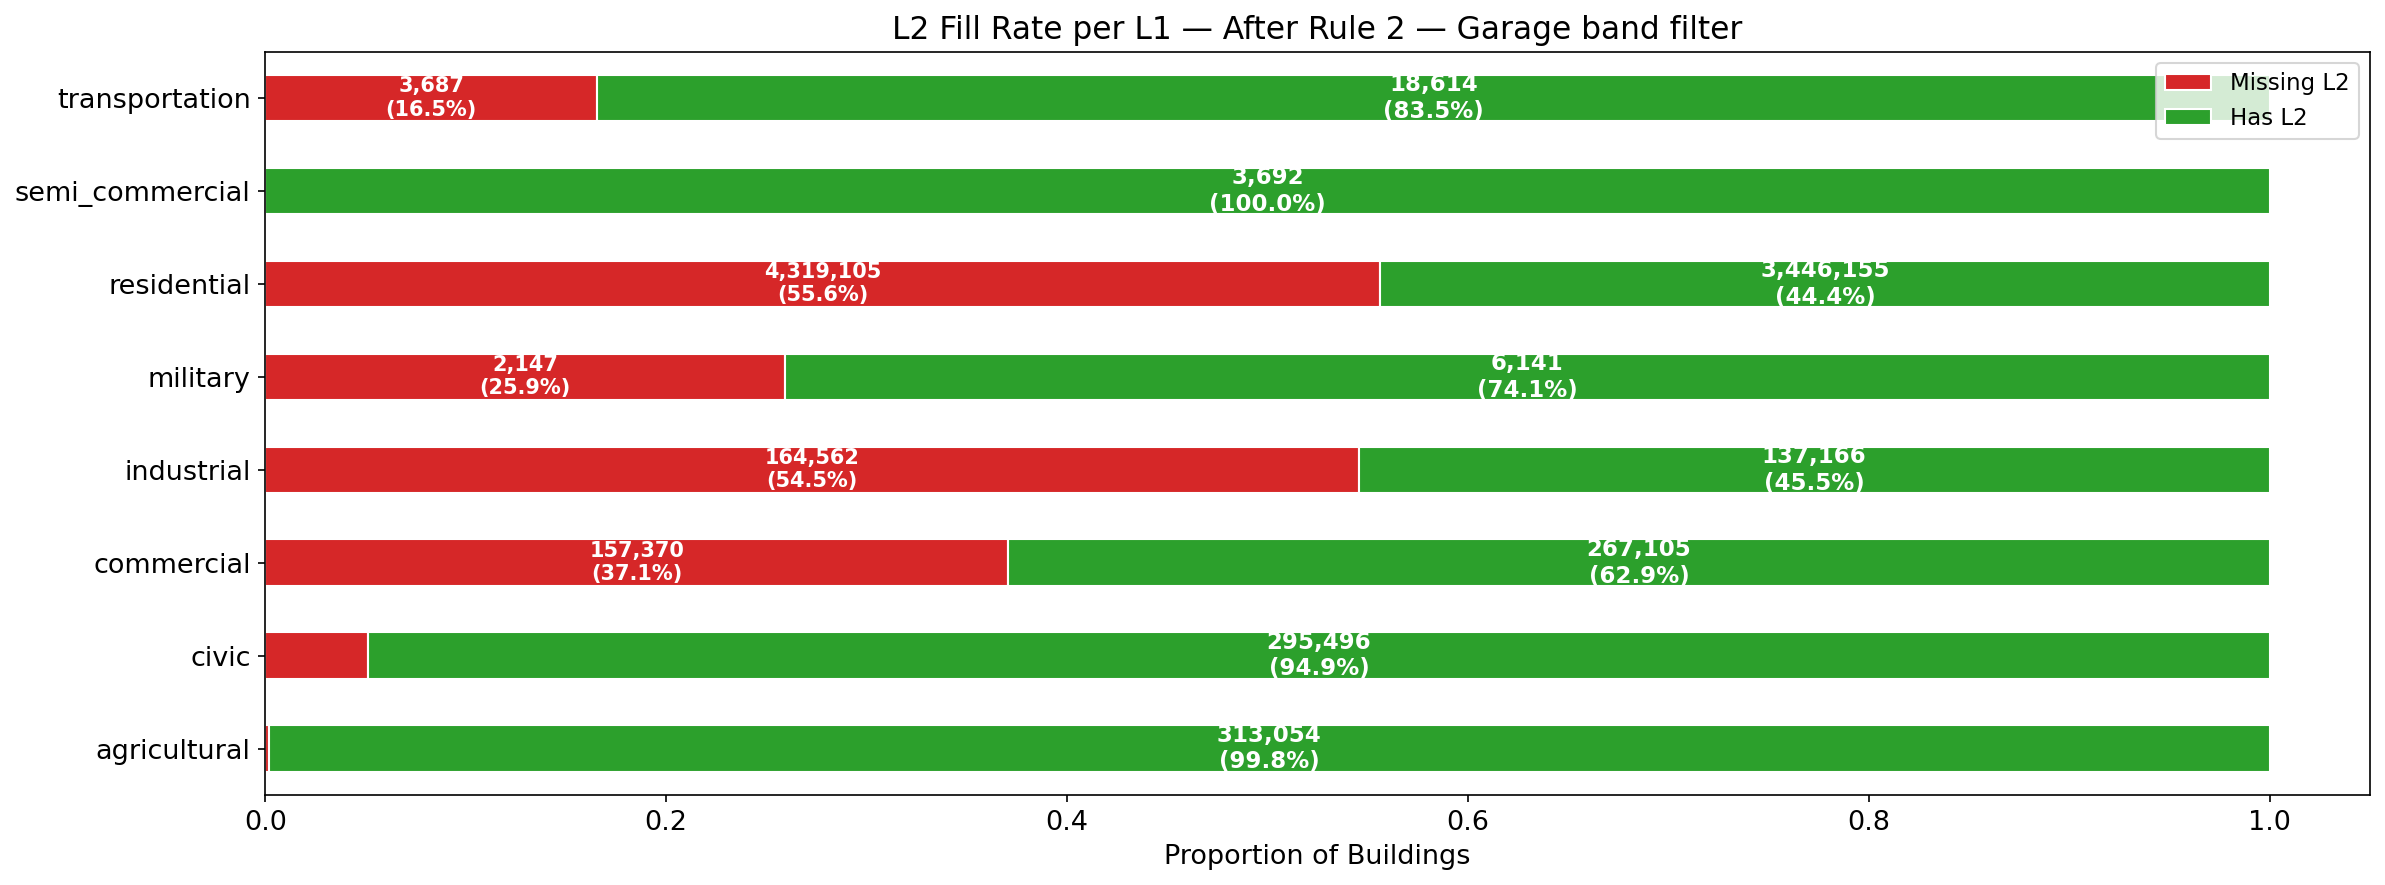

In [13]:
candidate_mask = (
    (unclassified_mask(gdf_bldg)) &
    var_candidate_mask)

candidates = gdf_bldg[candidate_mask].to_crs(epsg=3035)

print(f"Running 5-meter adjacency check on {len(candidates):,} candidate buildings...")
joined_gar = gpd.sjoin_nearest(
    candidates[['geometry', 'id']],
    addressed_houses[['geometry', 'id']],
    how='left', 
    max_distance=5, 
    distance_col='dist_to_house',
    lsuffix='cand', 
    rsuffix='house'
)
# (If a candidate is near multiple houses, it appears multiple times. Drop duplicates.)
has_neighbor = joined_gar.dropna(subset=['id_house']).drop_duplicates(subset=['id_cand'])
garage_ids = has_neighbor['id_cand'].values

r2_mask = gdf_bldg['id'].isin(garage_ids)

gdf_bldg.loc[r2_mask, 'stage2_l1']     = 'filter'
gdf_bldg.loc[r2_mask, 'stage2_l2']     = None
gdf_bldg.loc[r2_mask, 'stage2_source'] = 'rule2_garage_filter'

print(f"Rule 2 applied: {r2_mask.sum():,} buildings → filter/garage")
evaluate_step(gdf_bldg, "After Rule 2 — Garage band filter")

### Rule 3 – Classify Residential Buildings (80-200m²) with Address Information in Trusted Residential Zone

In [14]:
val_r3_mask = (
    (gdf_bldg['area_sqm'].between(80, 200)) & 
    (gdf_bldg['address_tier'] == 2) & gdf_bldg['landuse_osm_id'].isin(trusted_residential) # >0 ensures it has at least some address info
)

rule_precision_report(
    gdf_bldg, 
    val_r3_mask, 
    "Rule 3: 80-200m² + Has Address → residential landuse", 
    "residential"
)


──────────────────────────────────────────────────
  Rule: Rule 3: 80-200m² + Has Address → residential landuse  (filter buildings excluded from eval)
──────────────────────────────────────────────────
  Fires on tagged buildings : 2,340,916
  Correct (precision)       : 2,324,935  (99.3%)
  False positives           : 15,981  (0.7%)

  FP breakdown (what stage1 says):
stage1_l1
commercial         8706
civic              5154
industrial          785
semi_commercial     748
agricultural        474
transportation       96
military             18



Rule 3 applied: 1,433,865 buildings → residential

  After Rule 3 — Trusted addressed residential landuse zone (80-200m²)
  Total              :   38,802,372
  Classified         :   10,584,713  (27.3%)
    └ with L2        :    4,487,423  (42.4% of classified)
    └ no L2          :    6,097,290  (57.6% of classified)
  Filtered           :    9,822,755  (25.3%)
  Unclassified       :   18,394,904  (47.4%)

  ── Stage 2 contribution ──
  Added by stage2    :    1,433,865
  Filtered by stage2 :    5,701,511

  L1 breakdown (combined):
stage1_l1
None               18394904
filter              9822755
residential         9199122
commercial           424475
agricultural         313609
civic                311495
industrial           301728
transportation        22301
military               8288
semi_commercial        3695

  L2 breakdown (combined):
stage1_l2
None                         34314919
SFH                           1648916
MFH                           1470564
TH               

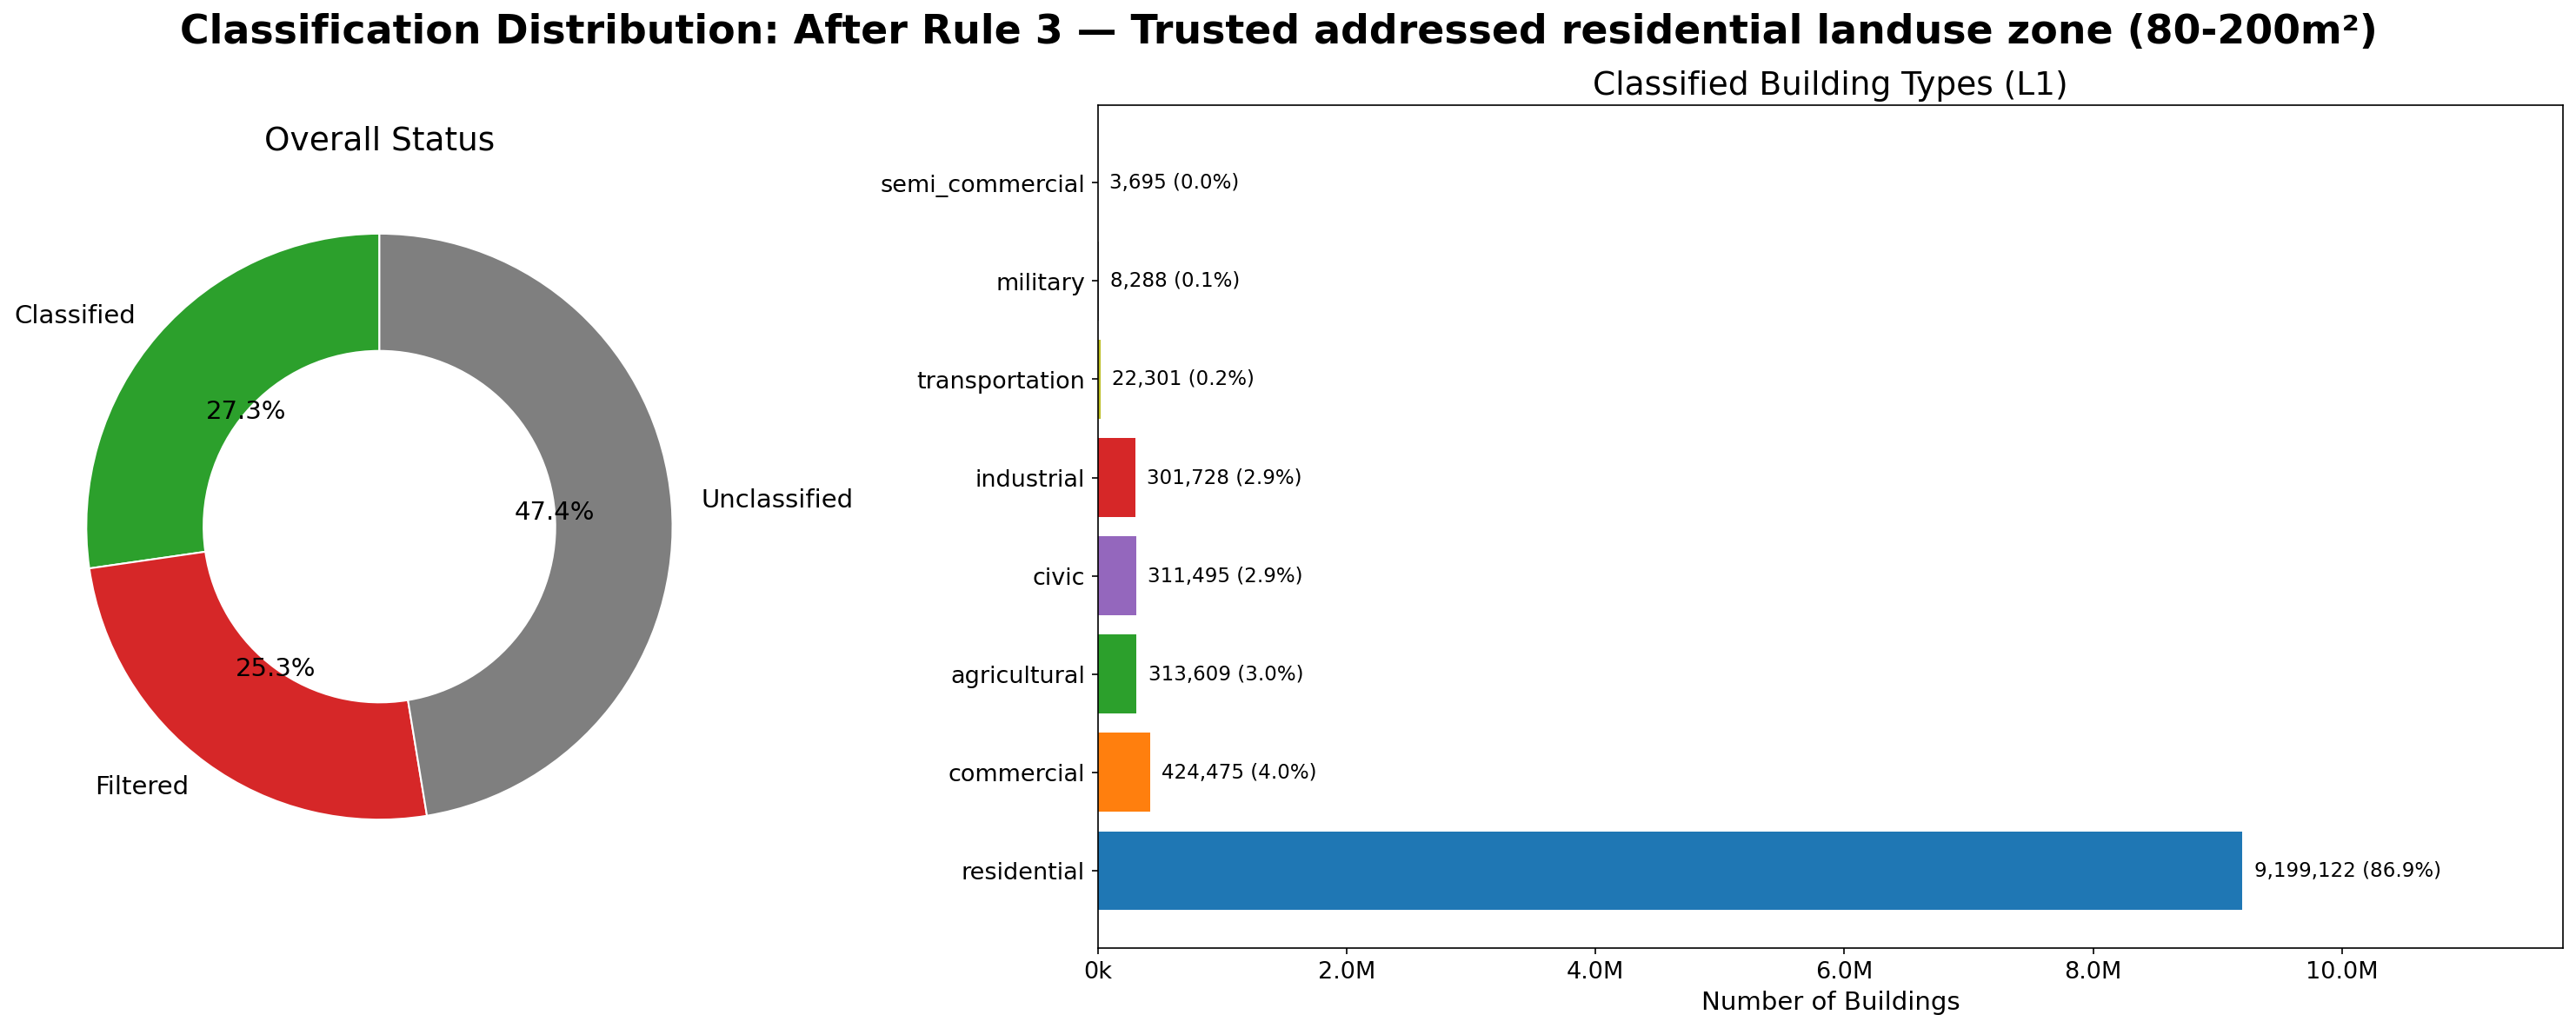

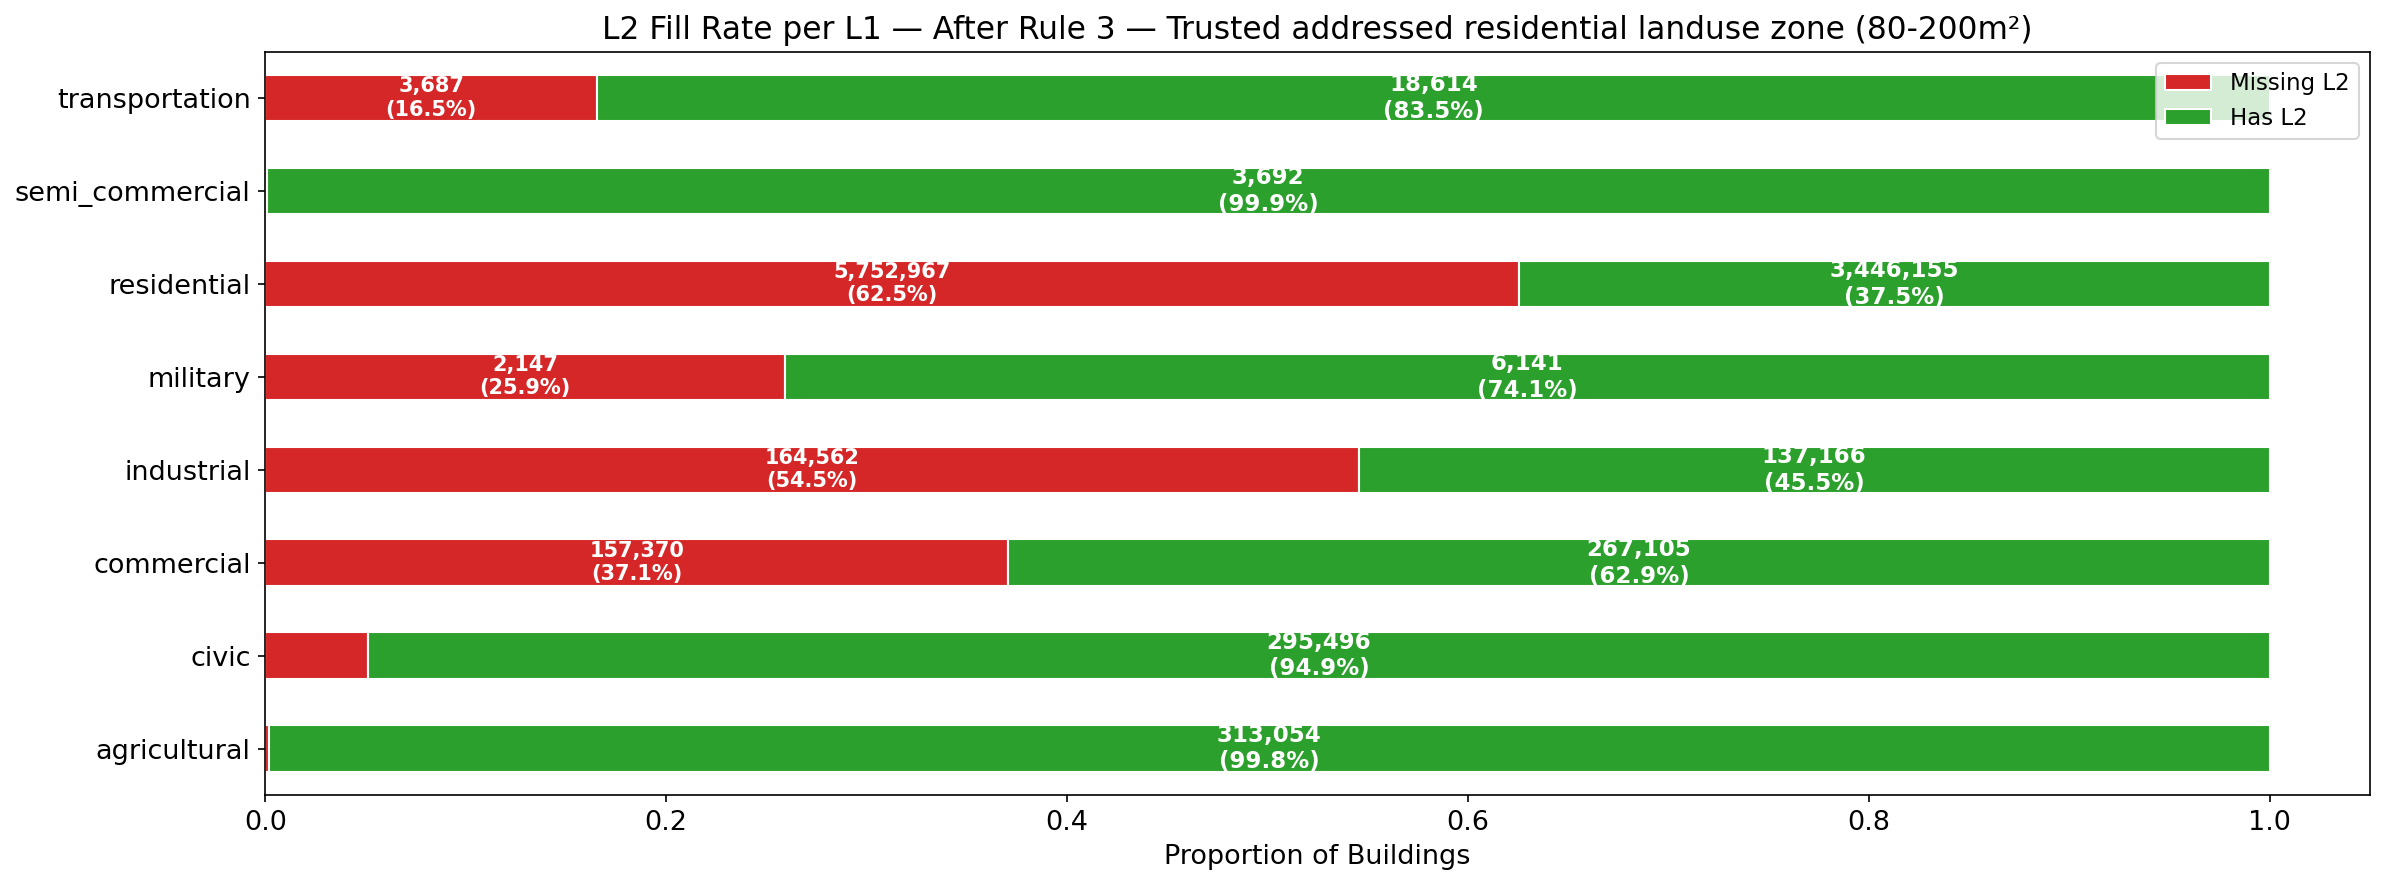

In [15]:
r3_mask = (
    unclassified_mask(gdf_bldg) & 
    val_r3_mask 
)

gdf_bldg.loc[r3_mask, 'stage2_l1']     = gdf_bldg.loc[r3_mask, 'landuse_l1']
gdf_bldg.loc[r3_mask, 'stage2_l2']     = gdf_bldg.loc[r3_mask, 'landuse_l2']
gdf_bldg.loc[r3_mask, 'stage2_source'] = 'rule3_trusted_residential_zone'

print(f"Rule 3 applied: {r3_mask.sum():,} buildings → residential")
evaluate_step(gdf_bldg, "After Rule 3 — Trusted addressed residential landuse zone (80-200m²)")

In [16]:
val_r4_mask = (
     gdf_bldg['landuse_osm_id'].isin(trusted_industrial) # >0 ensures it has at least some address info
)


rule_precision_report(
    gdf_bldg, 
    val_r4_mask, 
    "Trusted industrial landuse", 
    "industrial"
)


──────────────────────────────────────────────────
  Rule: Trusted industrial landuse  (filter buildings excluded from eval)
──────────────────────────────────────────────────
  Fires on tagged buildings : 58,726
  Correct (precision)       : 57,573  (98.0%)
  False positives           : 1,153  (2.0%)

  FP breakdown (what stage1 says):
stage1_l1
commercial        769
residential       161
civic             160
transportation     35
military           17
agricultural       11



Rule 4 applied: 44,970 buildings → industrial

  After Rule 4 — Trusted industrial landuse zone
  Total              :   38,802,372
  Classified         :   10,629,683  (27.4%)
    └ with L2        :    4,487,580  (42.2% of classified)
    └ no L2          :    6,142,103  (57.8% of classified)
  Filtered           :    9,822,755  (25.3%)
  Unclassified       :   18,349,934  (47.3%)

  ── Stage 2 contribution ──
  Added by stage2    :    1,478,835
  Filtered by stage2 :    5,701,511

  L1 breakdown (combined):
stage1_l1
None               18349934
filter              9822755
residential         9199122
commercial           424475
industrial           346698
agricultural         313609
civic                311495
transportation        22301
military               8288
semi_commercial        3695

  L2 breakdown (combined):
stage1_l2
None                         34314762
SFH                           1648916
MFH                           1470564
TH                             326675
farm_

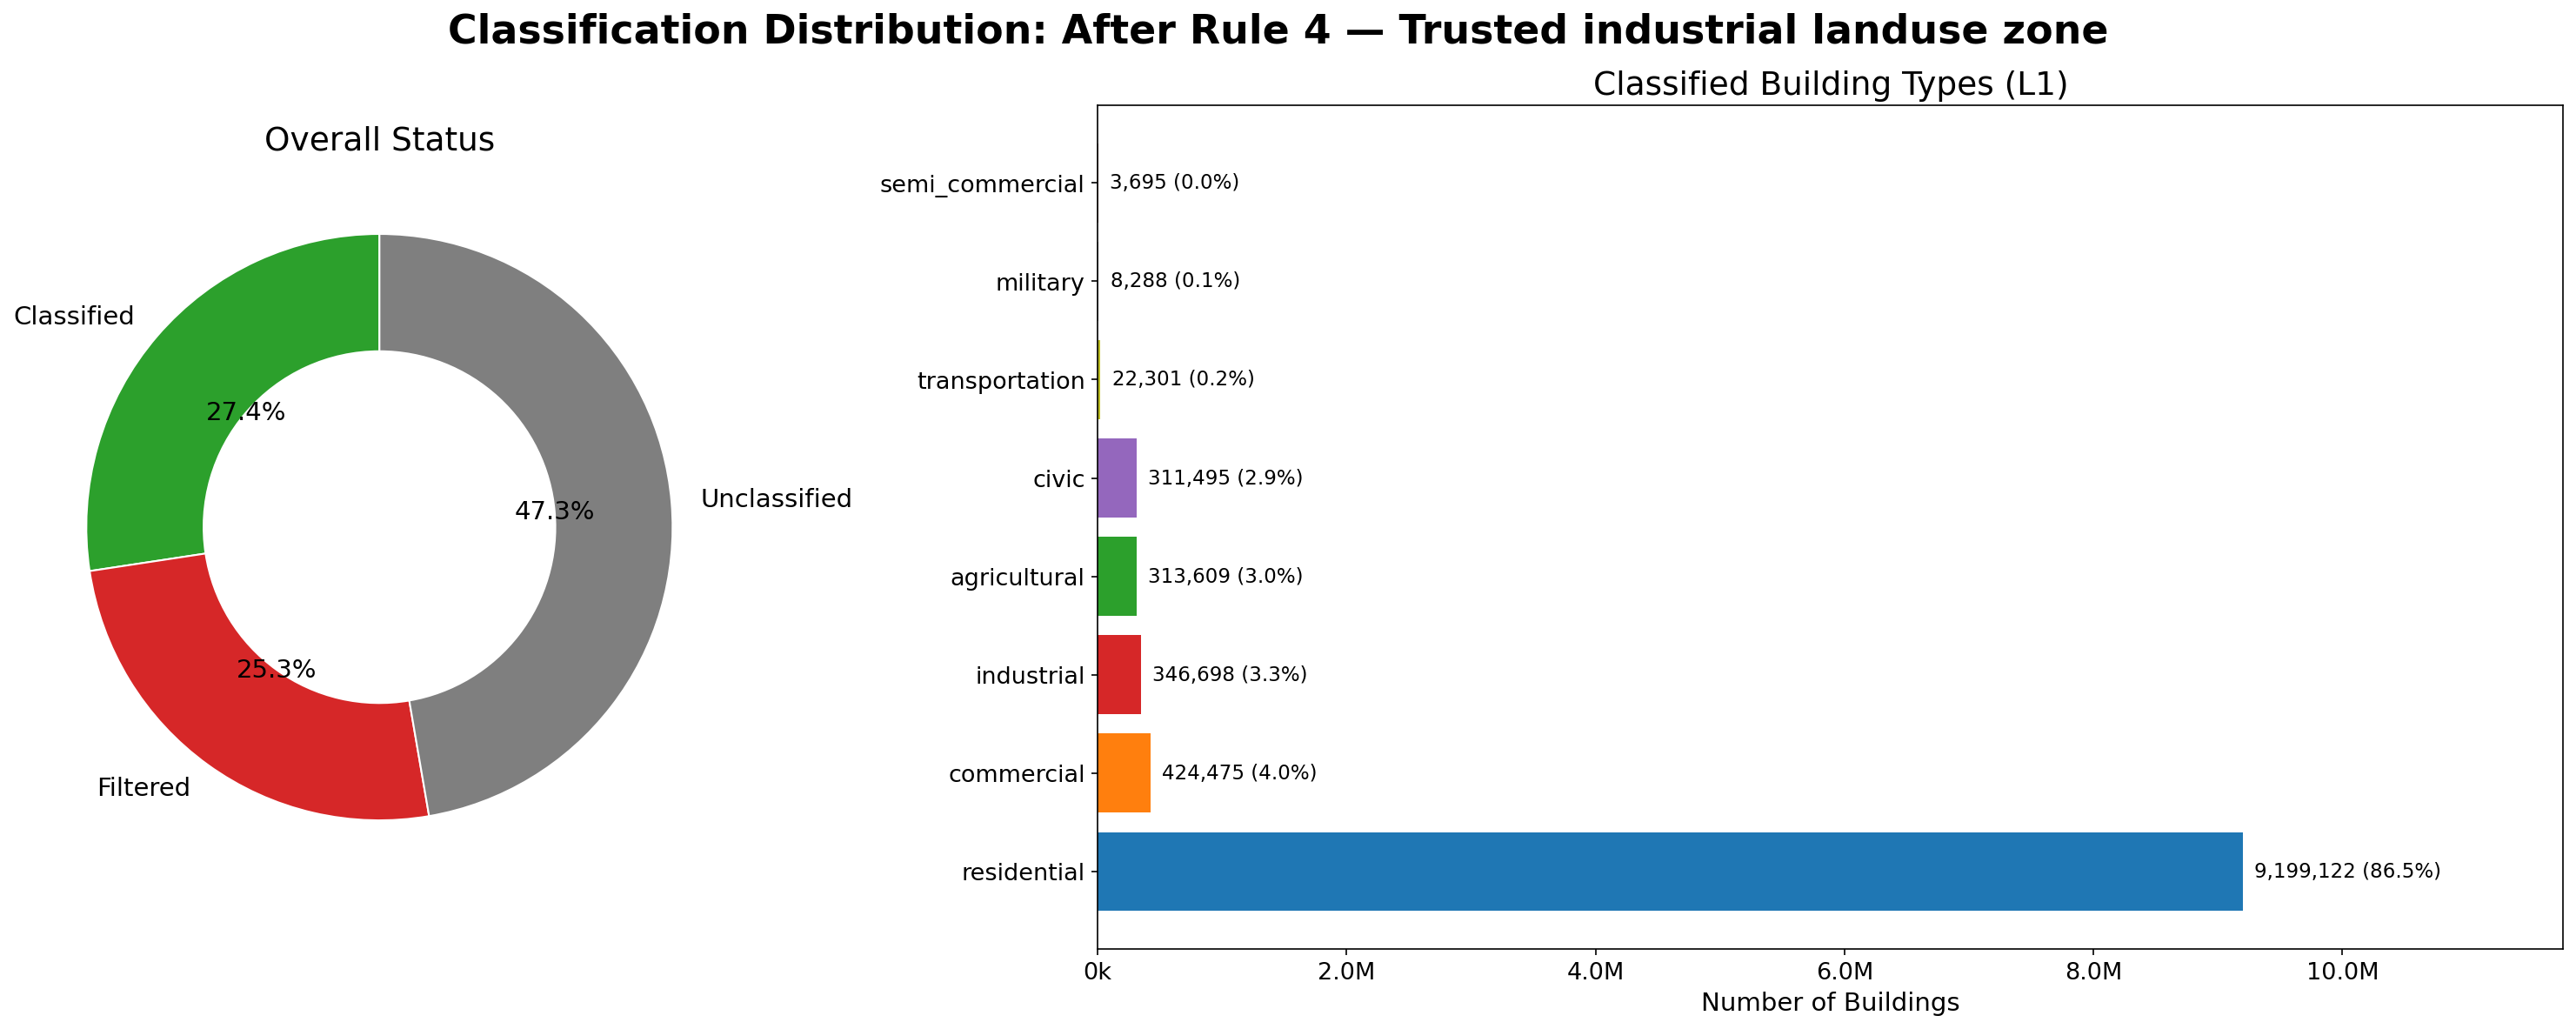

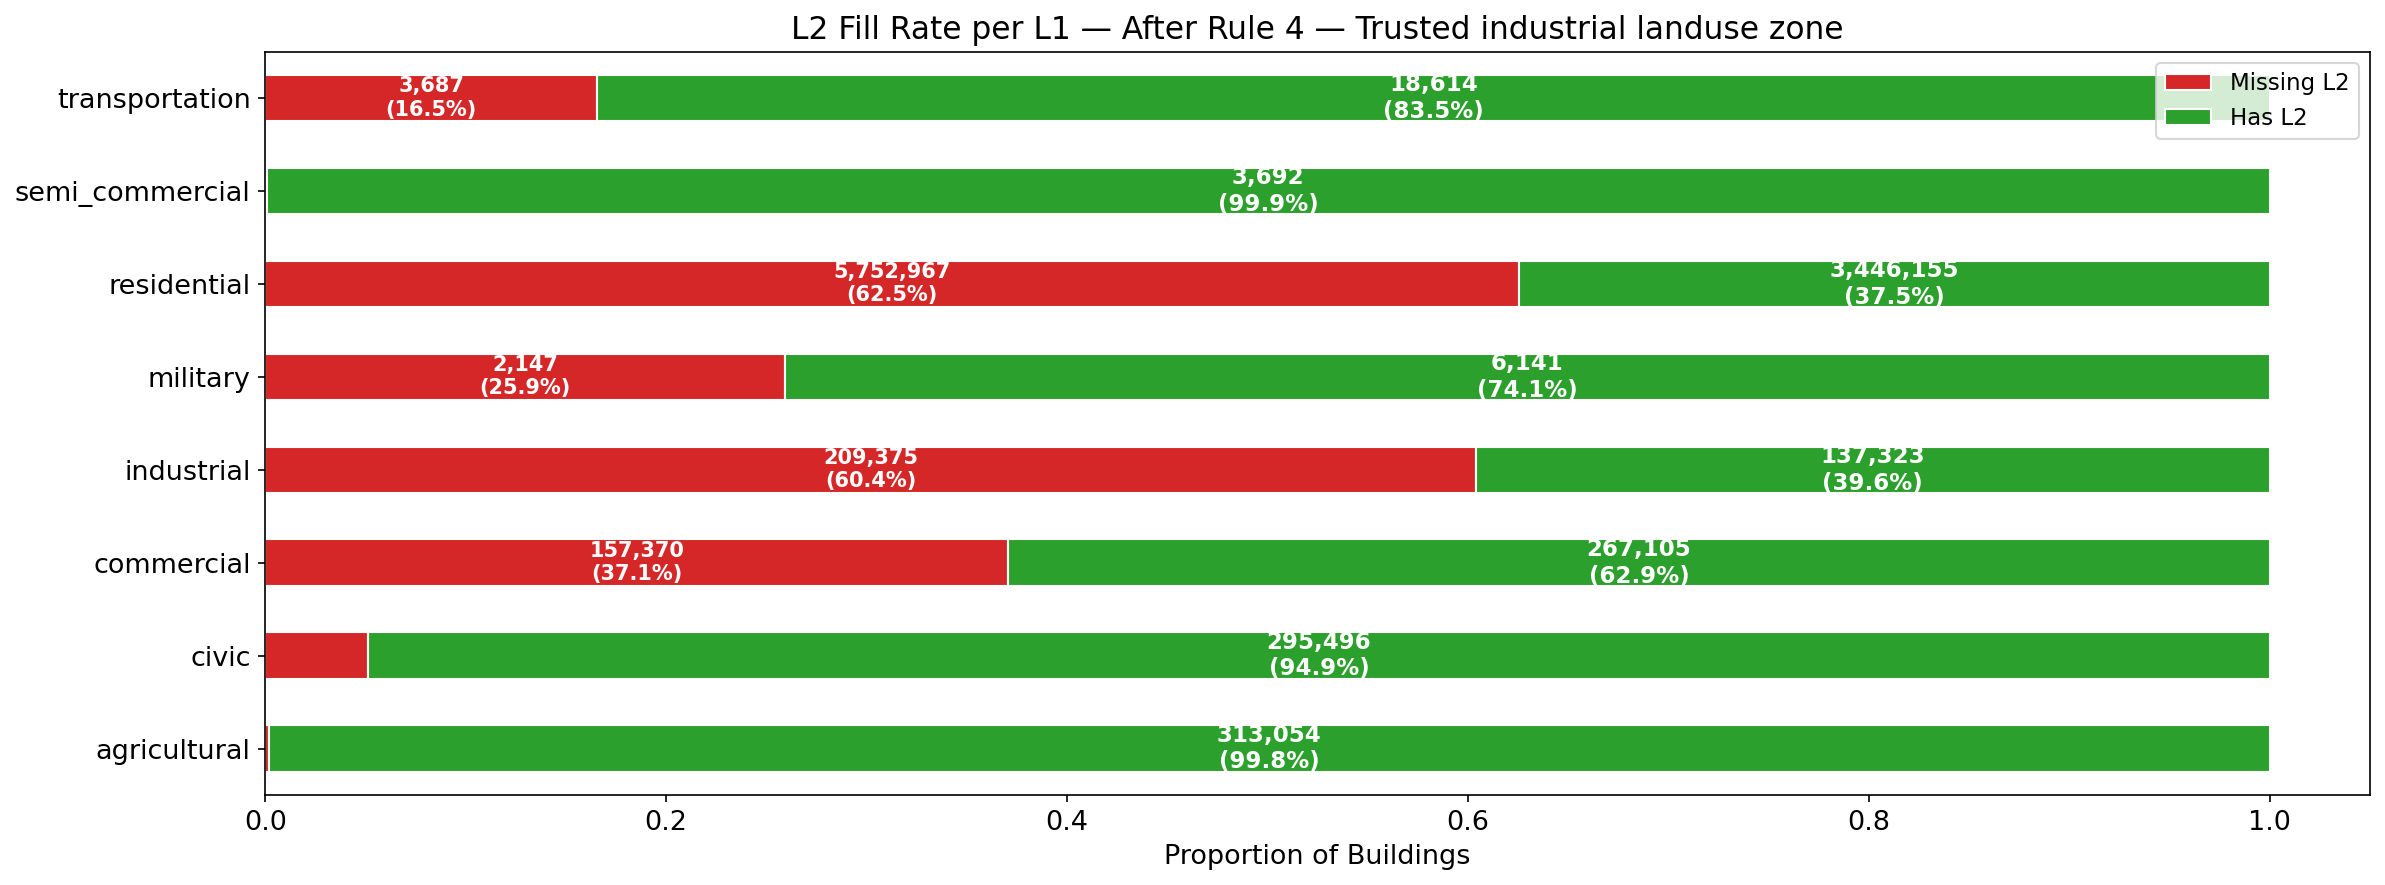

In [17]:
r4_mask = (
    unclassified_mask(gdf_bldg) & 
    val_r4_mask 
)

gdf_bldg.loc[r4_mask, 'stage2_l1']     = gdf_bldg.loc[r4_mask, 'landuse_l1']
gdf_bldg.loc[r4_mask, 'stage2_l2']     = gdf_bldg.loc[r4_mask, 'landuse_l2']
gdf_bldg.loc[r4_mask, 'stage2_source'] = 'rule4_trusted_industrial_zone'

print(f"Rule 4 applied: {r4_mask.sum():,} buildings → industrial")
evaluate_step(gdf_bldg, "After Rule 4 — Trusted industrial landuse zone")

In [18]:
val_r5_mask = (
     gdf_bldg['landuse_osm_id'].isin(trusted_commercial) 
    )

rule_precision_report(
    gdf_bldg, 
    val_r5_mask, 
    "Rule 5: Trusted commercial landuse", 
    "commercial"
)


──────────────────────────────────────────────────
  Rule: Rule 5: Trusted commercial landuse  (filter buildings excluded from eval)
──────────────────────────────────────────────────
  Fires on tagged buildings : 35,768
  Correct (precision)       : 35,171  (98.3%)
  False positives           : 597  (1.7%)

  FP breakdown (what stage1 says):
stage1_l1
industrial         291
residential        151
civic              101
transportation      37
agricultural        16
semi_commercial      1



Rule 5 applied: 29,785 buildings → commercial

  After Rule 5 — Trusted commercial landuse zone
  Total              :   38,802,372
  Classified         :   10,659,468  (27.5%)
    └ with L2        :    4,492,416  (42.1% of classified)
    └ no L2          :    6,167,052  (57.9% of classified)
  Filtered           :    9,822,755  (25.3%)
  Unclassified       :   18,320,149  (47.2%)

  ── Stage 2 contribution ──
  Added by stage2    :    1,508,620
  Filtered by stage2 :    5,701,511

  L1 breakdown (combined):
stage1_l1
None               18320149
filter              9822755
residential         9199122
commercial           454242
industrial           346698
agricultural         313609
civic                311495
transportation        22301
military               8288
semi_commercial        3713

  L2 breakdown (combined):
stage1_l2
None                         34309926
SFH                           1648916
MFH                           1470564
TH                             326675
farm_

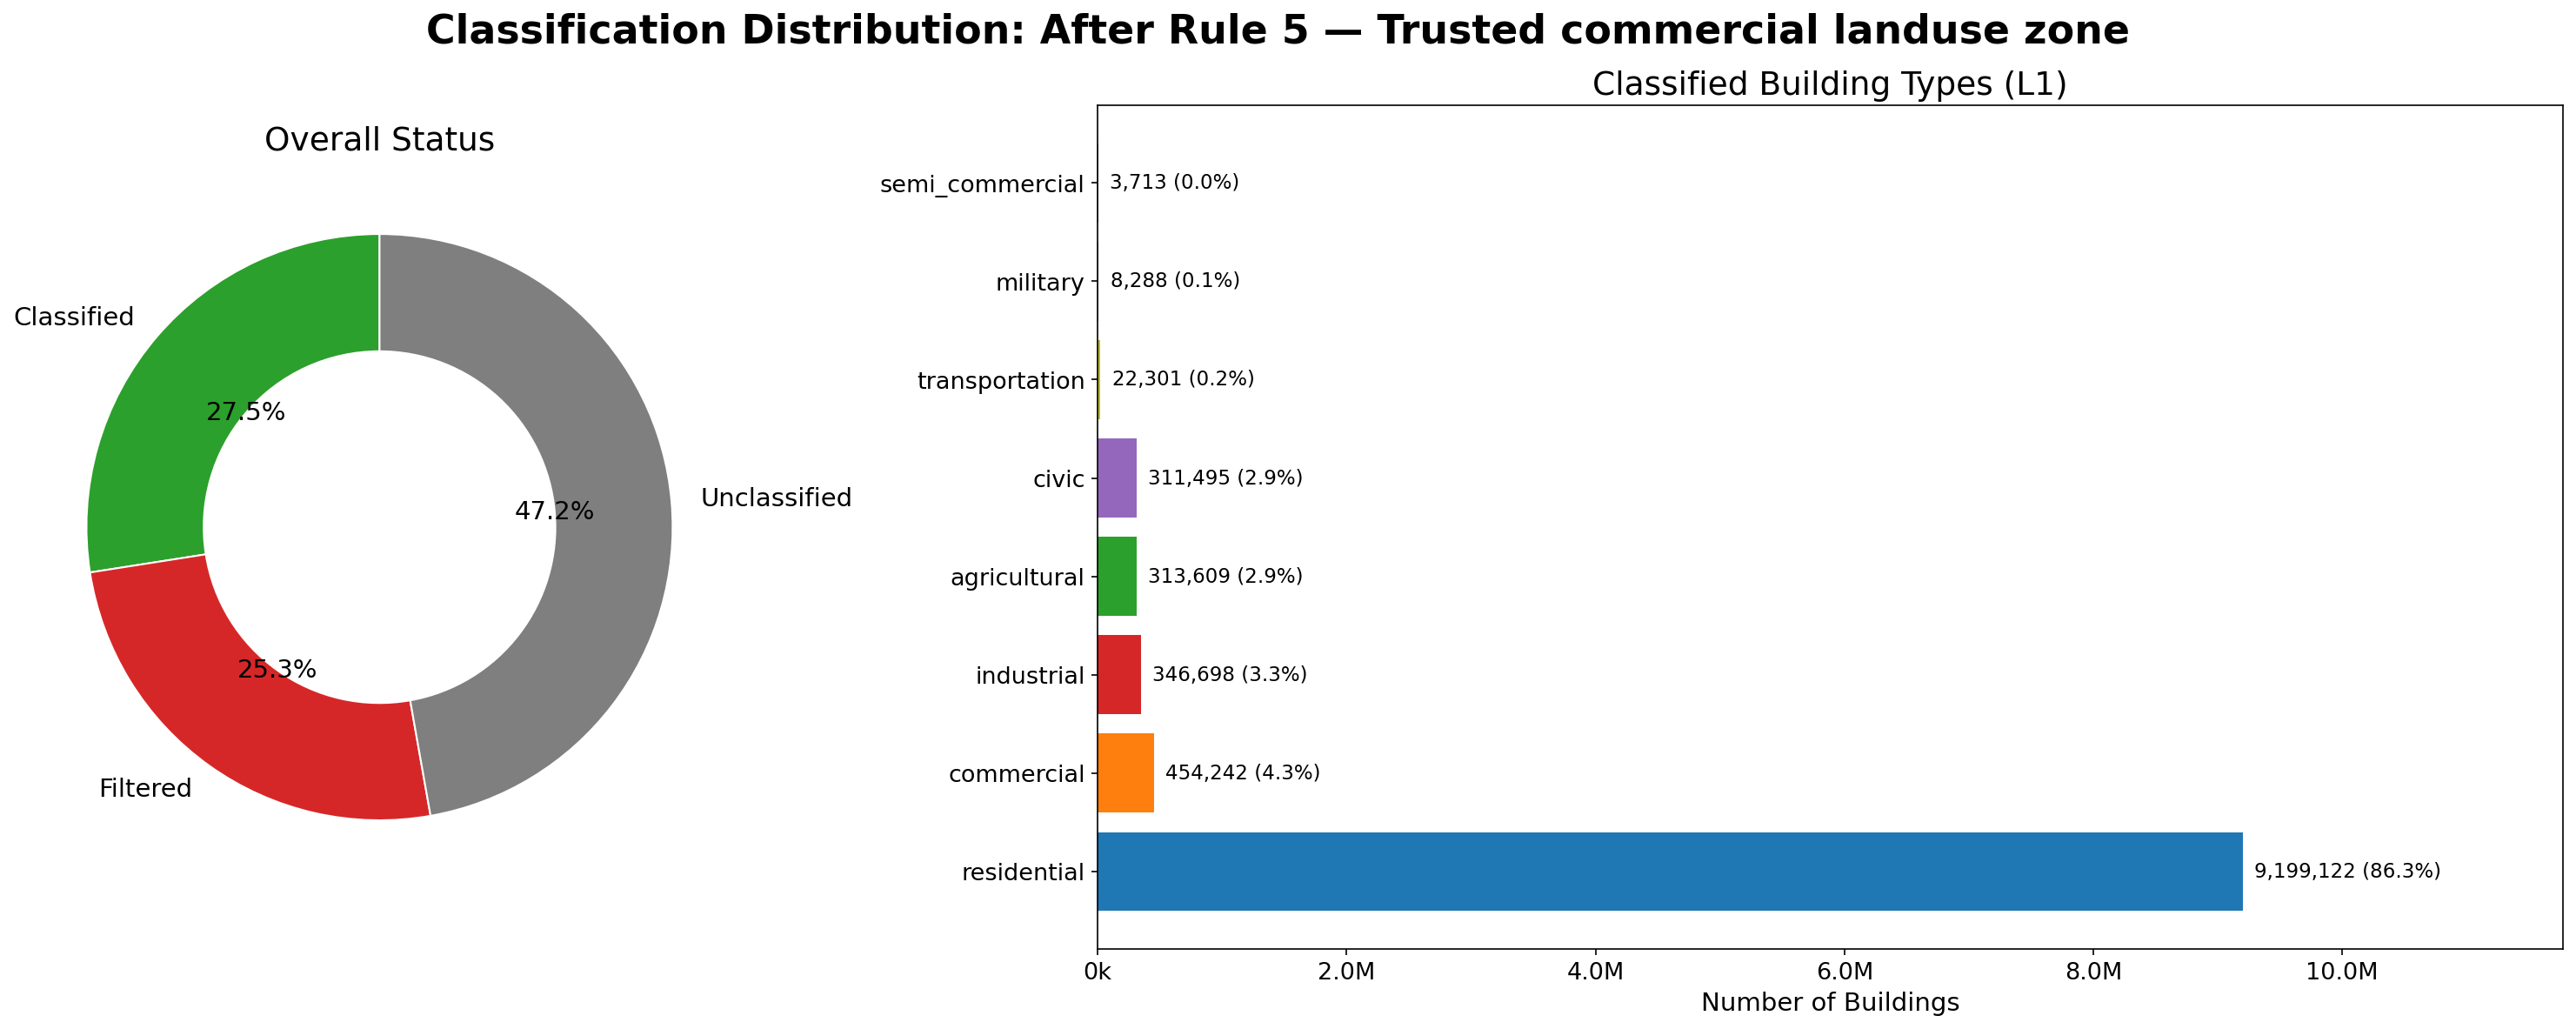

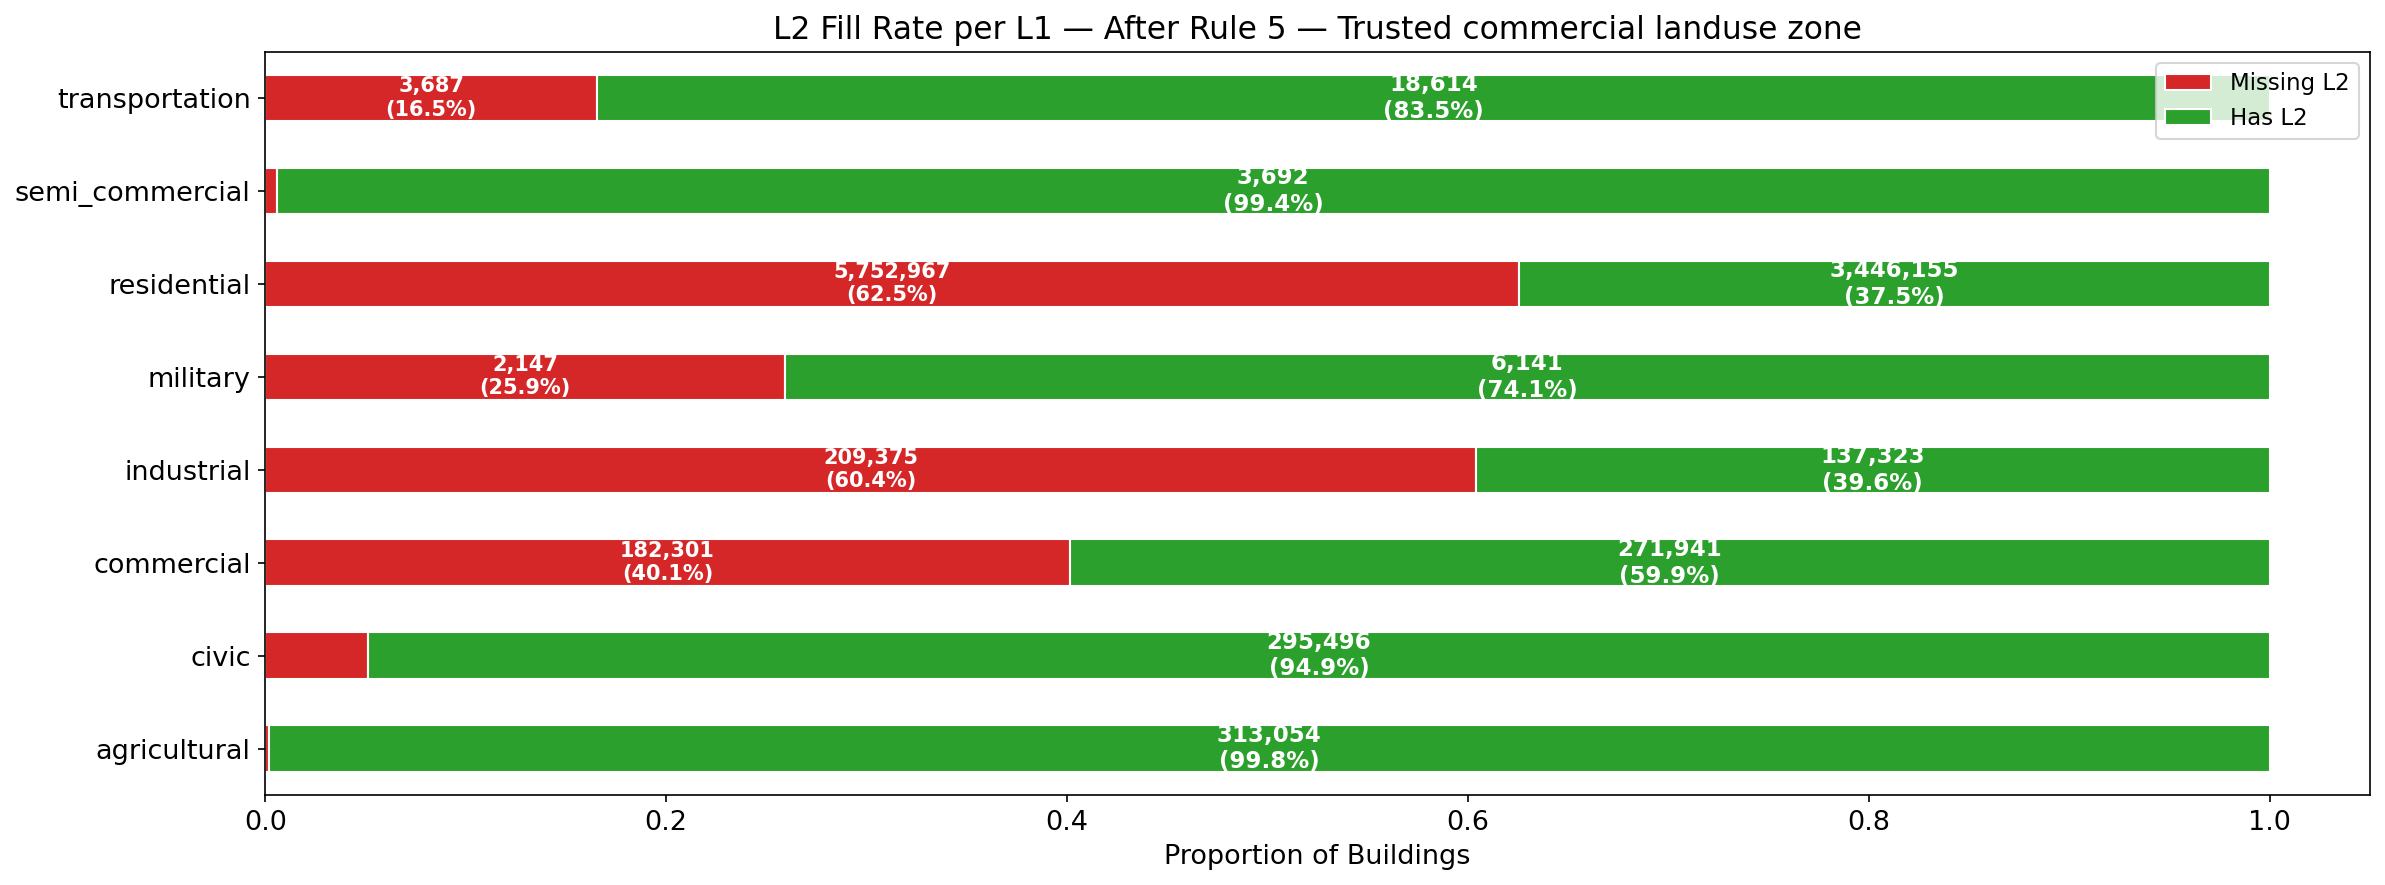

In [19]:
r5_mask = (
    unclassified_mask(gdf_bldg) & 
    val_r5_mask 
)

gdf_bldg.loc[r5_mask, 'stage2_l1']     = gdf_bldg.loc[r5_mask, 'landuse_l1']
gdf_bldg.loc[r5_mask, 'stage2_l2']     = gdf_bldg.loc[r5_mask, 'landuse_l2']
gdf_bldg.loc[r5_mask, 'stage2_source'] = 'rule5_trusted_commercial_zone'

print(f"Rule 5 applied: {r5_mask.sum():,} buildings → commercial")
evaluate_step(gdf_bldg, "After Rule 5 — Trusted commercial landuse zone")

In [20]:
val_r6_mask = (
     gdf_bldg['landuse_osm_id'].isin(trusted_military) 
    )

rule_precision_report(
    gdf_bldg, 
    val_r6_mask, 
    "Rule 6: Trusted military landuse", 
    "military"
)


──────────────────────────────────────────────────
  Rule: Rule 6: Trusted military landuse  (filter buildings excluded from eval)
──────────────────────────────────────────────────
  Fires on tagged buildings : 2,512
  Correct (precision)       : 2,495  (99.3%)
  False positives           : 17  (0.7%)

  FP breakdown (what stage1 says):
stage1_l1
industrial        7
civic             6
transportation    2
commercial        2



Rule 6 applied: 1,232 buildings → military

  After Rule 6 — Trusted military landuse zone
  Total              :   38,802,372
  Classified         :   10,660,700  (27.5%)
    └ with L2        :    4,492,416  (42.1% of classified)
    └ no L2          :    6,168,284  (57.9% of classified)
  Filtered           :    9,822,755  (25.3%)
  Unclassified       :   18,318,917  (47.2%)

  ── Stage 2 contribution ──
  Added by stage2    :    1,509,852
  Filtered by stage2 :    5,701,511

  L1 breakdown (combined):
stage1_l1
None               18318917
filter              9822755
residential         9199122
commercial           454242
industrial           346698
agricultural         313609
civic                311495
transportation        22301
military               9520
semi_commercial        3713

  L2 breakdown (combined):
stage1_l2
None                         34309926
SFH                           1648916
MFH                           1470564
TH                             326675
farm_auxil

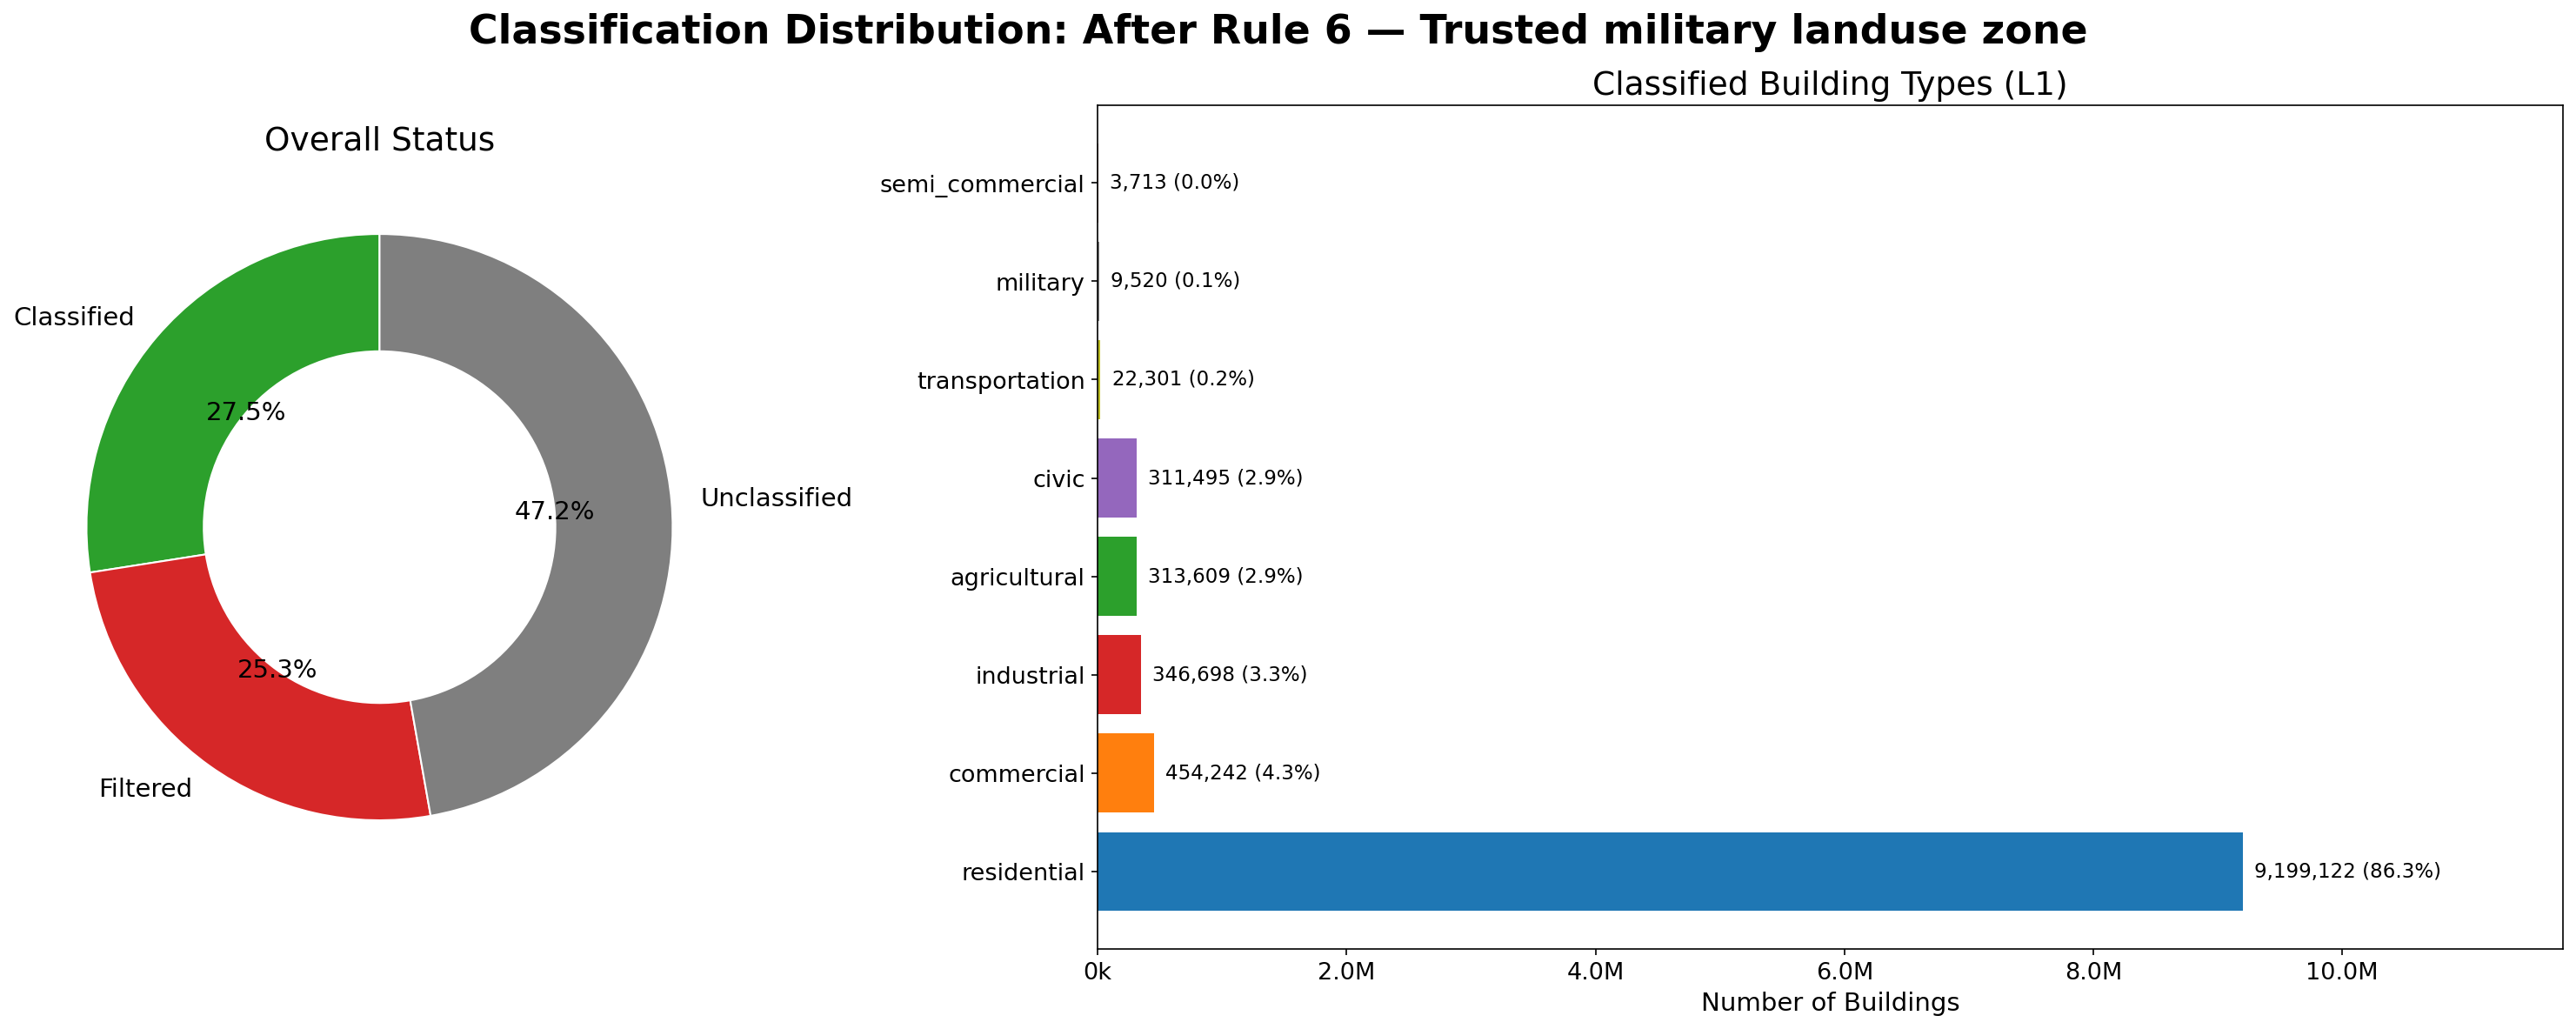

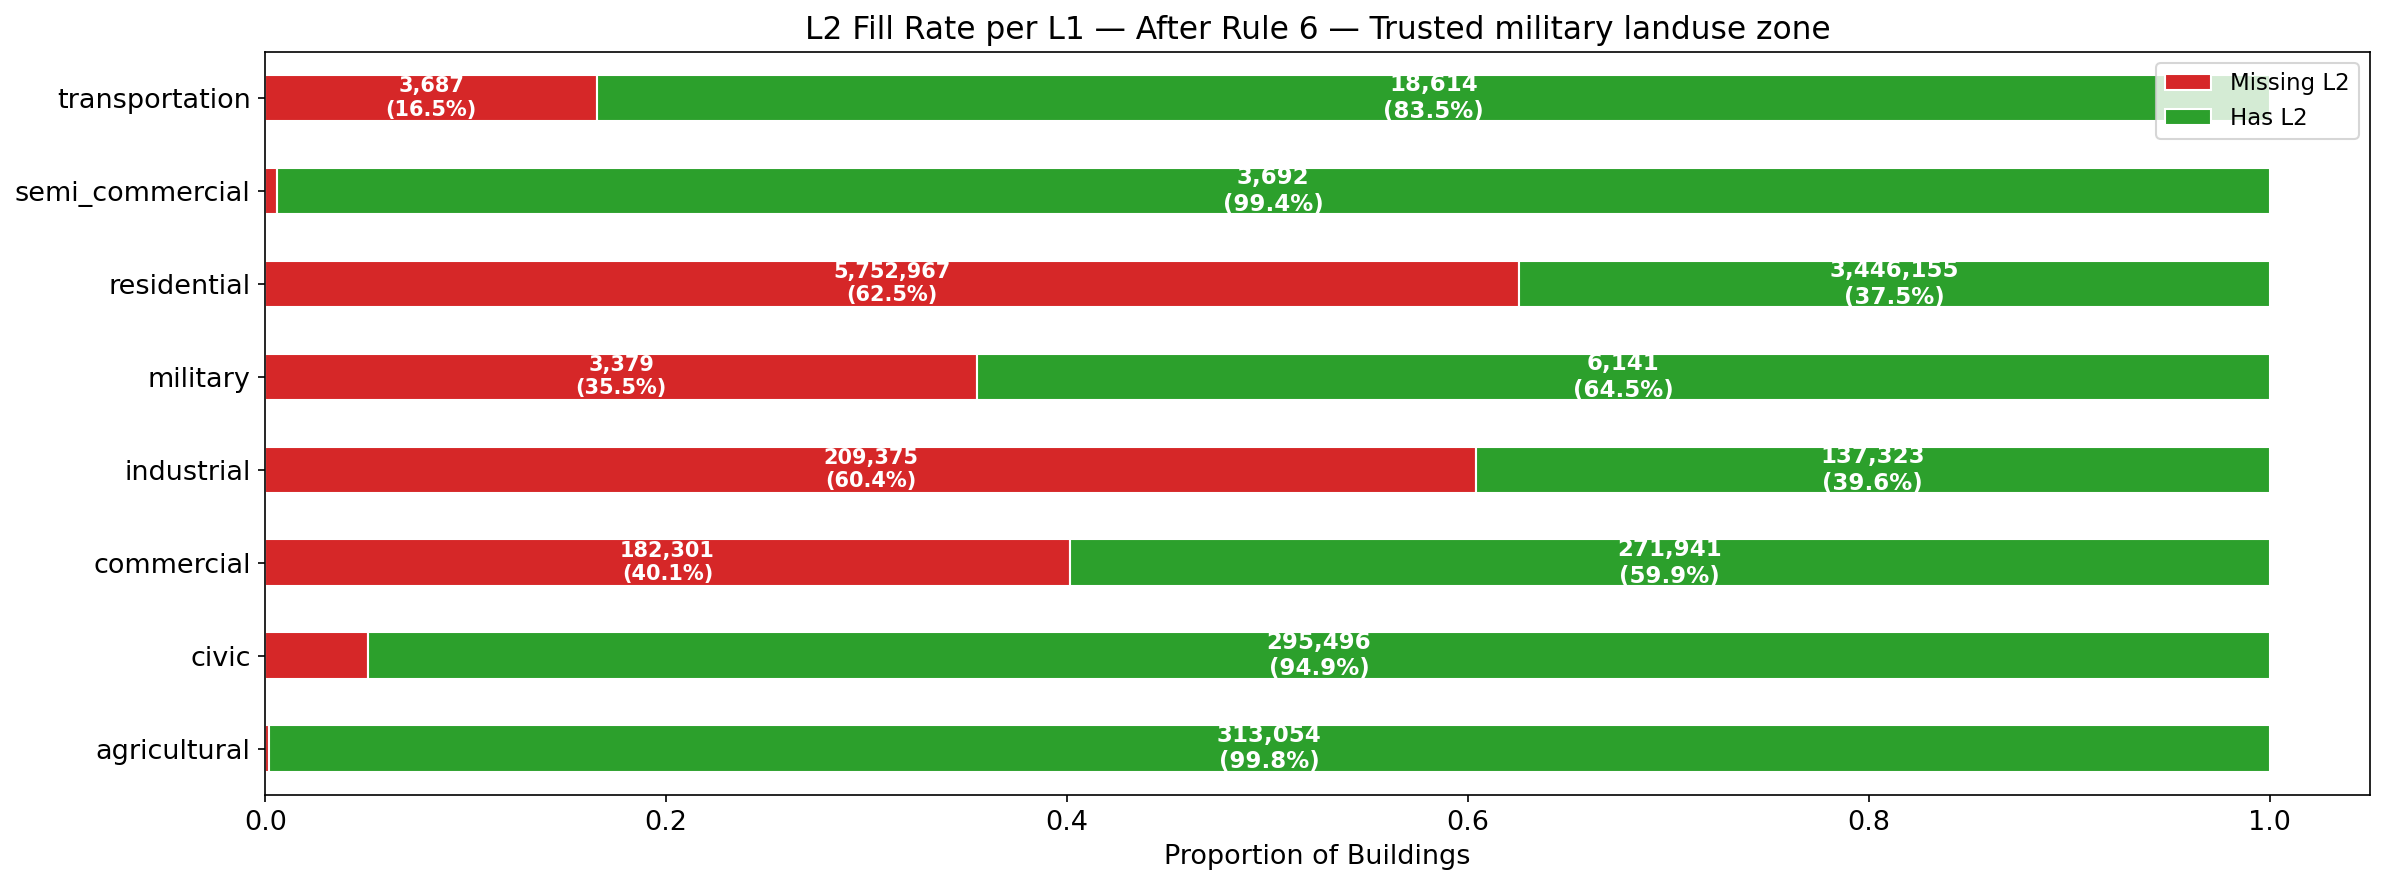

In [21]:
r6_mask = (
    unclassified_mask(gdf_bldg) & 
    val_r6_mask 
)

gdf_bldg.loc[r6_mask, 'stage2_l1']     = gdf_bldg.loc[r6_mask, 'landuse_l1']
gdf_bldg.loc[r6_mask, 'stage2_l2']     = gdf_bldg.loc[r6_mask, 'landuse_l2']
gdf_bldg.loc[r6_mask, 'stage2_source'] = 'rule6_trusted_military_zone'

print(f"Rule 6 applied: {r6_mask.sum():,} buildings → military")
evaluate_step(gdf_bldg, "After Rule 6 — Trusted military landuse zone")


RULE 7 — Polygon POI centroid contained → inherit (guarded)

  CIVIC — source precision (min 10 buildings):
                               n  precision
poi_source                                 
amenity+building            20.0      1.000
amenity+university          36.0      0.944
amenity+school            1953.0      0.913
amenity                  95476.0      0.897
amenity+college             53.0      0.811
amenity+police             229.0      0.306
museum                     661.0      0.222
amenity+social_facility   4917.0      0.177
zoo                        614.0      0.067
  Trusted sources for civic: {'school', 'amenity+building', 'amenity', 'amenity+kindergarten', 'amenity+library', 'amenity+school', 'amenity+school+social_facility', 'social_facility', 'amenity+university', 'amenity+childcare'}

  AGRICULTURAL — source precision (min 10 buildings):
                n  precision
poi_source                  
amenity     985.0      0.759
  Trusted sources for agricultural: s

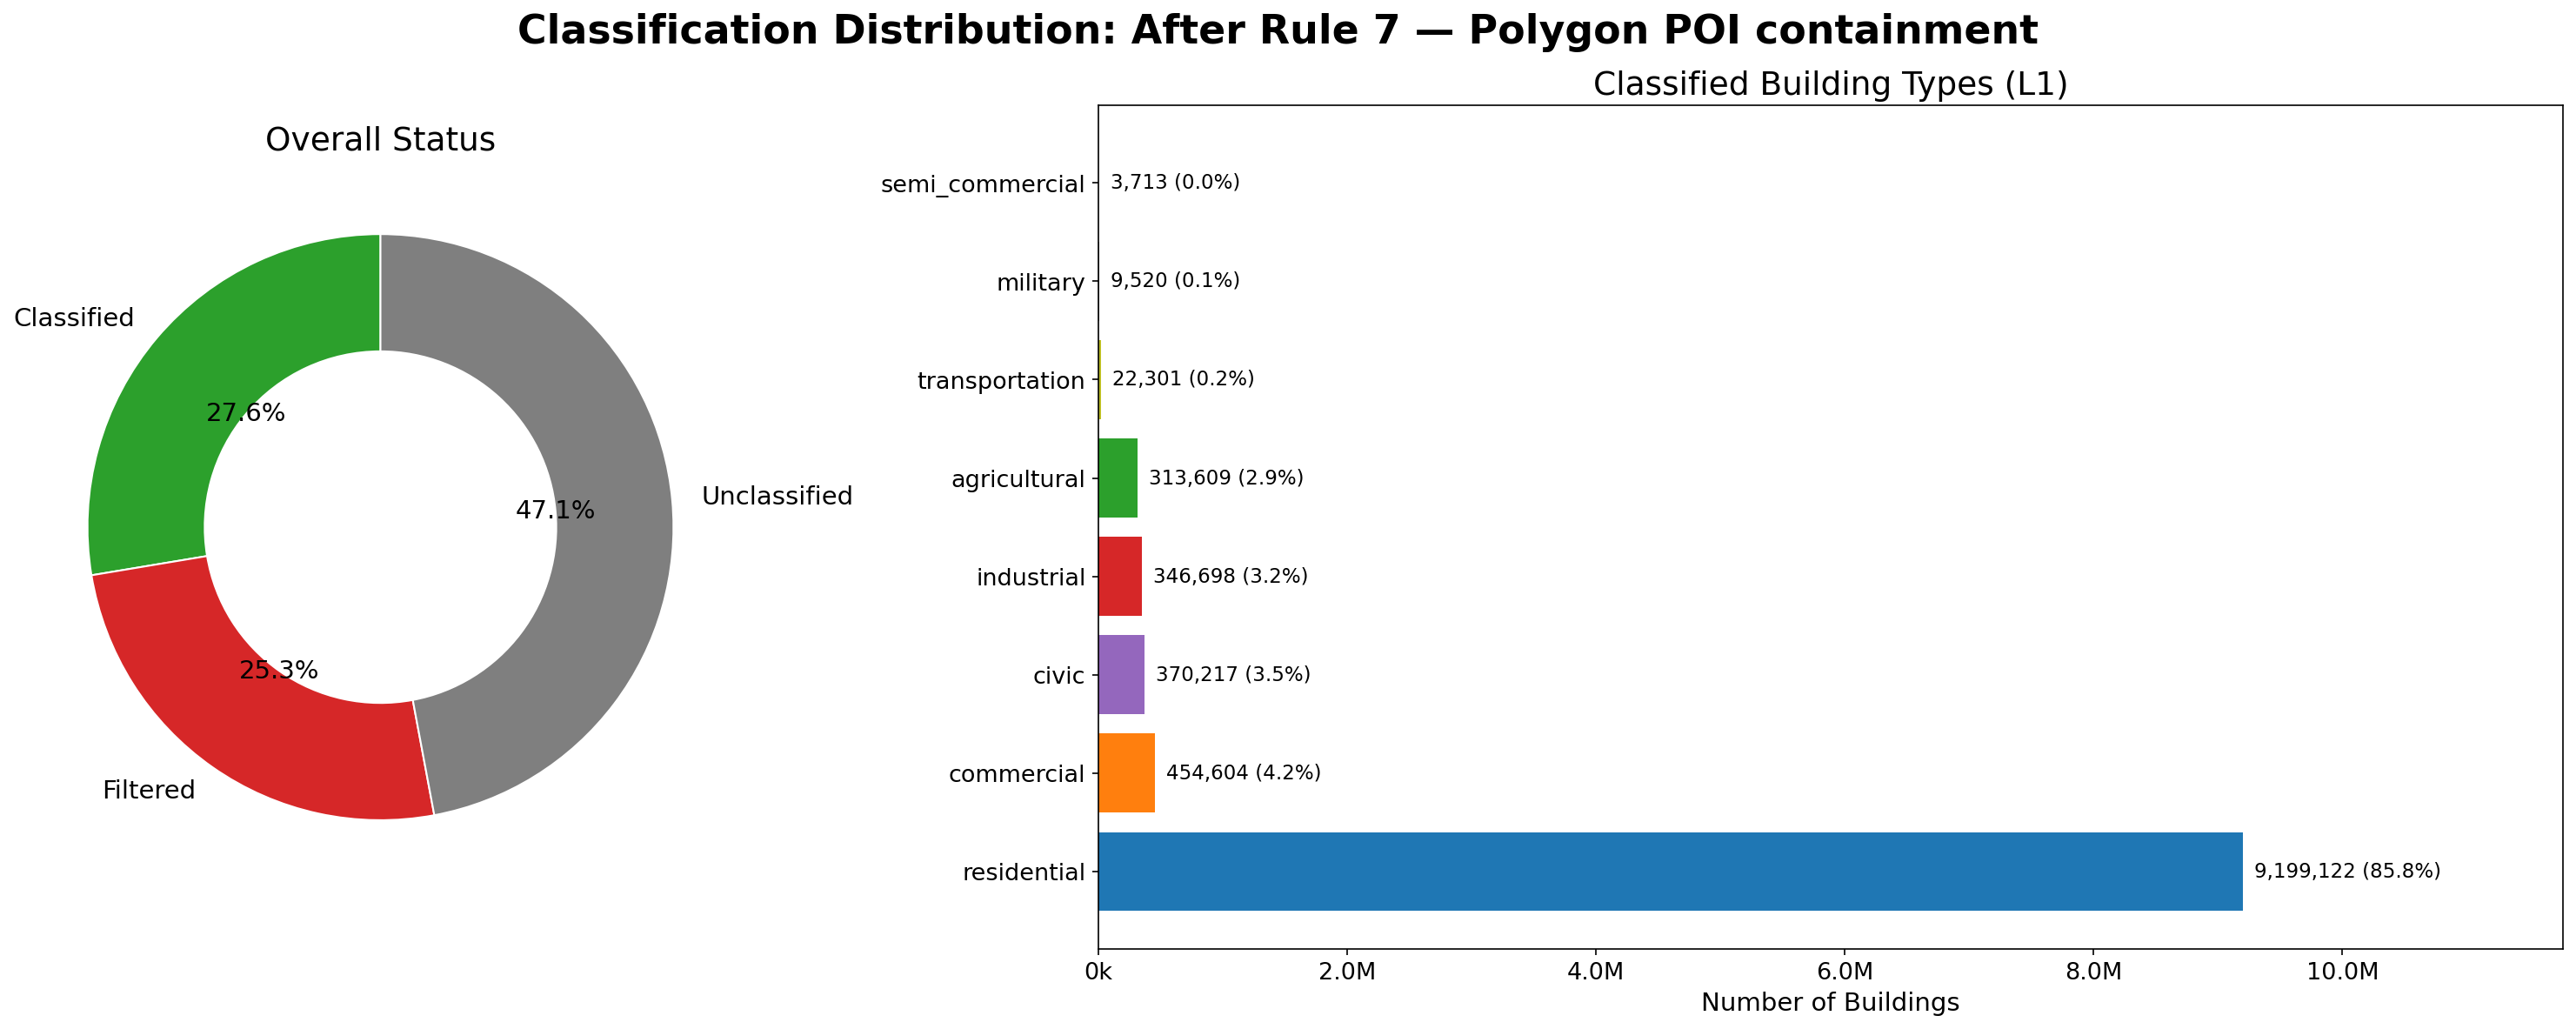

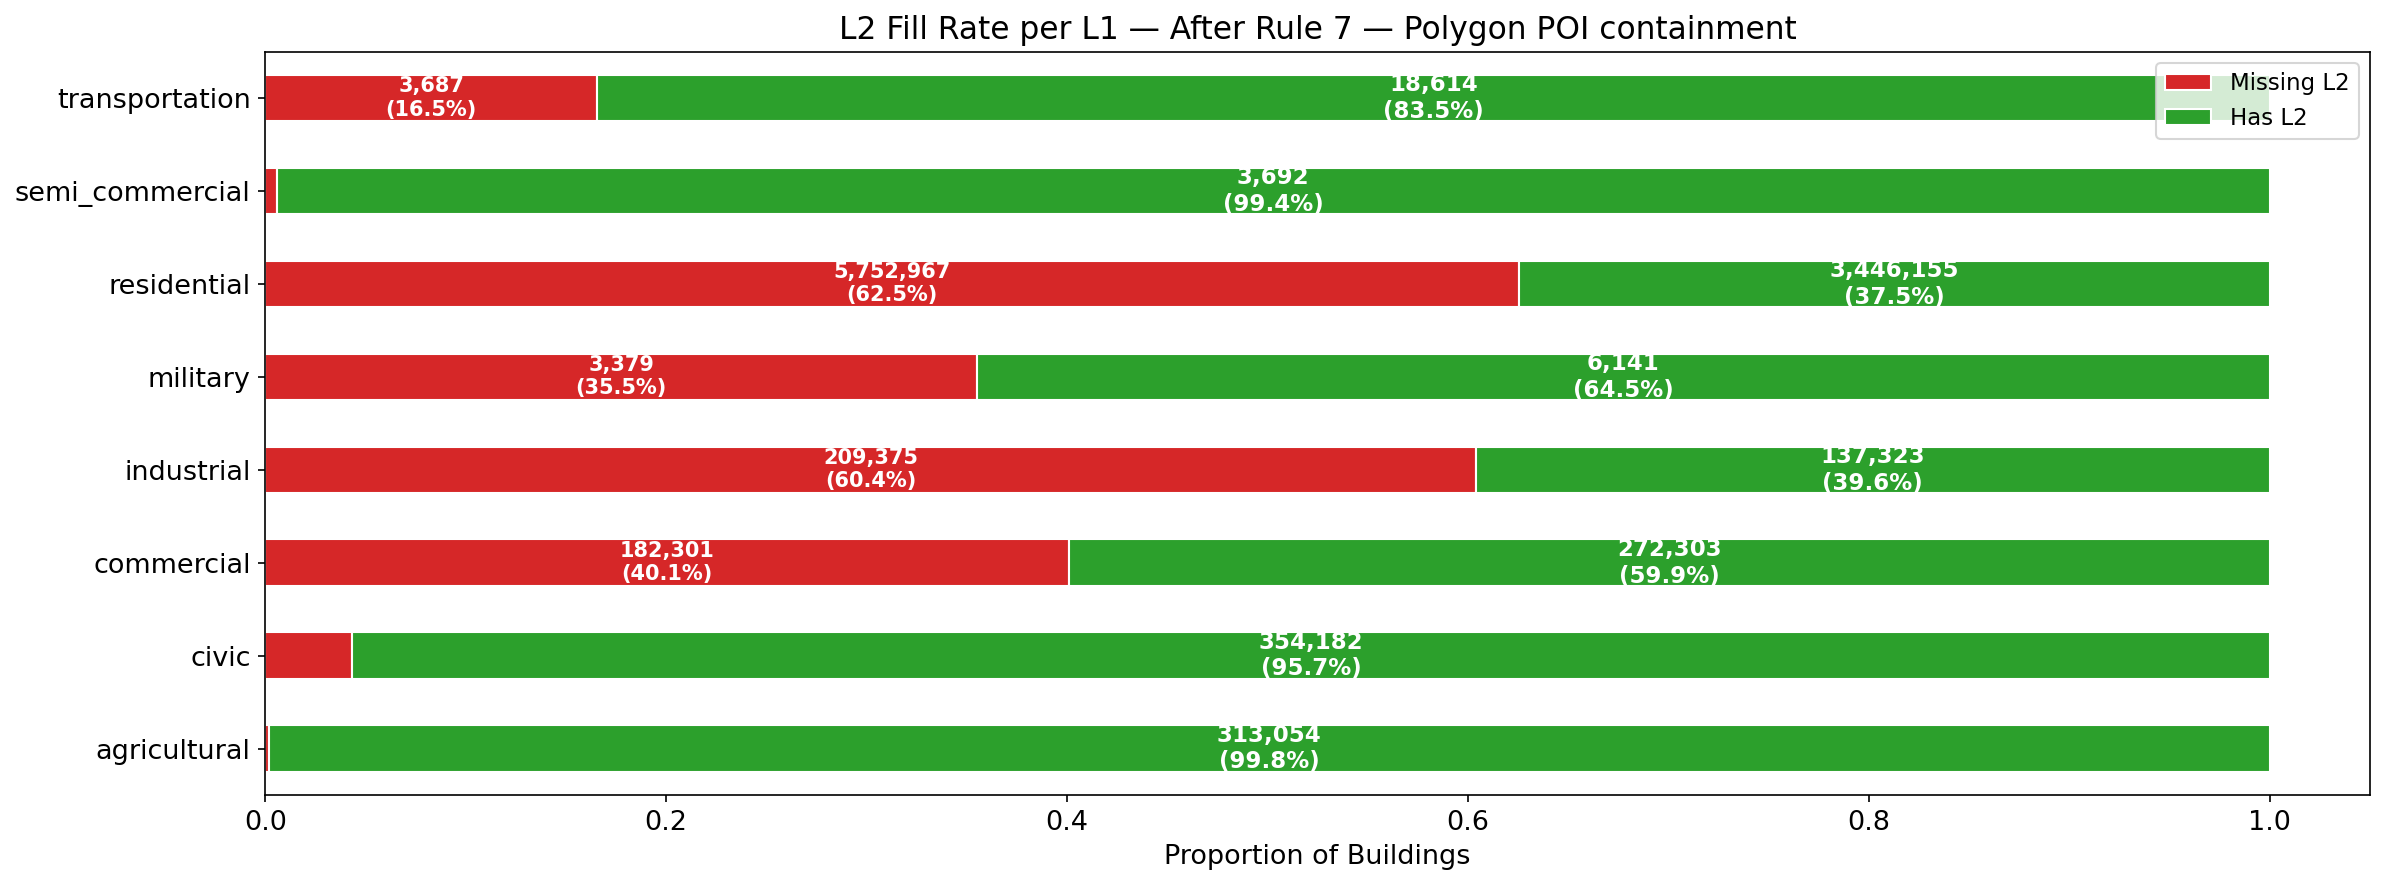

In [22]:
# ── RULE 7 — Polygon POI centroid containment → inherit ────────────
print("\n" + "="*55)
print("RULE 7 — Polygon POI centroid contained → inherit (guarded)")
print("="*55)

POLY_CONTAIN_TRUSTED_L1 = {'civic', 'commercial', 'agricultural'}


MIN_SOURCE_PRECISION  = 0.85
MIN_SOURCE_BUILDINGS  = 10    # minimum buildings to evaluate a source

if len(poi_in_bldg) > 0:

    # ── Step 1: merge stage1 ground truth for source evaluation ──────────────
    # We need stage1_l1 on the contained frame to evaluate sources.
    # Only tagged (non-null, non-filter) buildings are used for evaluation.
    poly_eval = poi_in_bldg.merge(
        gdf_bldg[['id', 'stage1_l1']],
        left_on='bldg_id', right_on='id',
        how='left'
    )

    # ── Step 2: per-L1-type source precision filtering ────────────────────────
    # For each trusted L1, compute precision per source and keep only
    # sources that meet the threshold.
    trusted_source_sets = {}   # l1_type → set of trusted poi_source values

    for l1_type in POLY_CONTAIN_TRUSTED_L1:
        subset_eval = poly_eval[
            (poly_eval['poi_l1'] == l1_type) &
            poly_eval['stage1_l1'].notna() &
            (poly_eval['stage1_l1'] != 'filter')
        ]

        if len(subset_eval) == 0:
            print(f"  {l1_type}: no tagged buildings to evaluate sources — keeping all sources")
            trusted_source_sets[l1_type] = None   # None = keep all
            continue

        src_prec = (
            subset_eval
            .groupby('poi_source')
            .apply(
                lambda x: pd.Series({
                    'n':         len(x),
                    'precision': (x['stage1_l1'] == l1_type).mean()
                }),
                include_groups=False
            )
            .round(3)
            .sort_values('precision', ascending=False)
        )

        print(f"\n  {l1_type.upper()} — source precision (min {MIN_SOURCE_BUILDINGS} buildings):")
        evaluable = src_prec[src_prec['n'] >= MIN_SOURCE_BUILDINGS]
        if len(evaluable) > 0:
            print(evaluable.to_string())
        else:
            print(f"    No sources with >= {MIN_SOURCE_BUILDINGS} buildings")

        trusted = set(
            src_prec[
                (src_prec['n']         >= MIN_SOURCE_BUILDINGS) &
                (src_prec['precision'] >= MIN_SOURCE_PRECISION)
            ].index
        )

        # Sources with too few buildings to evaluate
        unevaluable = set(src_prec[src_prec['n'] < MIN_SOURCE_BUILDINGS].index)
        trusted = trusted | unevaluable

        trusted_source_sets[l1_type] = trusted
        print(f"  Trusted sources for {l1_type}: {trusted}")

    # ── Step 2b: overall precision per L1 after source filter ────────────────
    # Shows the net effect of the source filter before any assignment happens.
    print(f"\n{'─'*55}")
    print(f"  Overall precision per L1 after source filter")
    print(f"{'─'*55}")

    for l1_type in POLY_CONTAIN_TRUSTED_L1:
        trusted_srcs = trusted_source_sets[l1_type]

        # Filter poly_eval to this L1 type + trusted sources
        type_eval = poly_eval[
            (poly_eval['poi_l1'] == l1_type) &
            poly_eval['stage1_l1'].notna() &
            (poly_eval['stage1_l1'] != 'filter')
        ]
        if trusted_srcs is not None:
            type_eval = type_eval[type_eval['poi_source'].isin(trusted_srcs)]

        if len(type_eval) == 0:
            print(f"  {l1_type:<15}: no tagged buildings to evaluate")
            continue

        n        = len(type_eval)
        prec     = (type_eval['stage1_l1'] == l1_type).mean()
        fp_count = n - int(prec * n)

        print(f"  {l1_type:<15}: {prec:.1%}  (n={n:,}, FP={fp_count:,})")

        if fp_count > 0:
            fp_rows = type_eval[type_eval['stage1_l1'] != l1_type]
            top_fps = fp_rows['stage1_l1'].value_counts().head(4)
            for wrong_l1, count in top_fps.items():
                print(f"    └ actually {wrong_l1:<20}: {count:,}")

    print(f"{'─'*55}")
    print(f"  (Threshold: {MIN_SOURCE_PRECISION:.0%} — types below this should be dropped)")
    print()
    
    # ── Step 3: build the clean contained frame with source filter applied ────
    poly_contain_clean = poi_in_bldg[
        poi_in_bldg['poi_l1'].isin(POLY_CONTAIN_TRUSTED_L1) &
        poi_in_bldg['poi_l1'].notna()
    ].copy()

    # Apply source filter per L1 type
    keep_mask = pd.Series(False, index=poly_contain_clean.index)
    for l1_type, trusted_srcs in trusted_source_sets.items():
        l1_rows = poly_contain_clean['poi_l1'] == l1_type
        if trusted_srcs is None:
            # No source filtering for this type — keep all
            keep_mask = keep_mask | l1_rows
        else:
            keep_mask = keep_mask | (
                l1_rows & poly_contain_clean['poi_source'].isin(trusted_srcs)
            )

    poly_contain_clean = poly_contain_clean[keep_mask].drop_duplicates('bldg_id').copy()
    print(f"\n  Rows after source filter: {len(poly_contain_clean):,}")

    # ── Step 4: apply per-L1 area + address guards and assign ────────────────
    total_applied = 0
    for l1_type in POLY_CONTAIN_TRUSTED_L1:
        subset    = poly_contain_clean[poly_contain_clean['poi_l1'] == l1_type]
        
        candidate_mask = (
            unclassified_mask(gdf_bldg) &
            gdf_bldg['id'].isin(subset['bldg_id']) 
        )
        
        # ── Precision validation BEFORE applying ─────────────────────────────
        rule_precision_report(
            gdf_bldg, candidate_mask,
            f"Rule 7 ({l1_type}): polygon POI contained, ",
            assigned_l1=l1_type,
            exclude_filtered=True   # filter buildings irrelevant here
        )

        apply_idx = gdf_bldg.index[candidate_mask]
        if len(apply_idx) == 0:
            print(f"  {l1_type}: 0 buildings passed guards — skipped")
            continue

        lookup   = subset.set_index('bldg_id')
        bldg_ids = gdf_bldg.loc[apply_idx, 'id']

        gdf_bldg.loc[apply_idx, 'stage2_l1'] = (
            bldg_ids.map(lookup['poi_l1']).values
        )
        gdf_bldg.loc[apply_idx, 'stage2_l2'] = (
            bldg_ids.map(lookup['poi_l2']).values
        )
        gdf_bldg.loc[apply_idx, 'stage2_source'] = f'rule7_polygon_poi_contained_{l1_type}'

        total_applied += len(apply_idx)

    print(f"\nRule 7 total applied: {total_applied:,}")

else:
    print("  Skipped — poi_in_bldg not loaded.")

evaluate_step(gdf_bldg, "After Rule 7 — Polygon POI containment")


STAGE 2 COMPLETE — Final Summary

  Final — Stage 2 Complete
  Total              :   38,802,372
  Classified         :   10,719,784  (27.6%)
    └ with L2        :    4,551,464  (42.5% of classified)
    └ no L2          :    6,168,320  (57.5% of classified)
  Filtered           :    9,822,755  (25.3%)
  Unclassified       :   18,259,833  (47.1%)

  ── Stage 2 contribution ──
  Added by stage2    :    1,568,936
  Filtered by stage2 :    5,701,511

  L1 breakdown (combined):
stage1_l1
None               18259833
filter              9822755
residential         9199122
commercial           454604
civic                370217
industrial           346698
agricultural         313609
transportation        22301
military               9520
semi_commercial        3713

  L2 breakdown (combined):
stage1_l2
None                         34250878
SFH                           1648916
MFH                           1470564
TH                             326675
farm_auxiliary                 241815
r

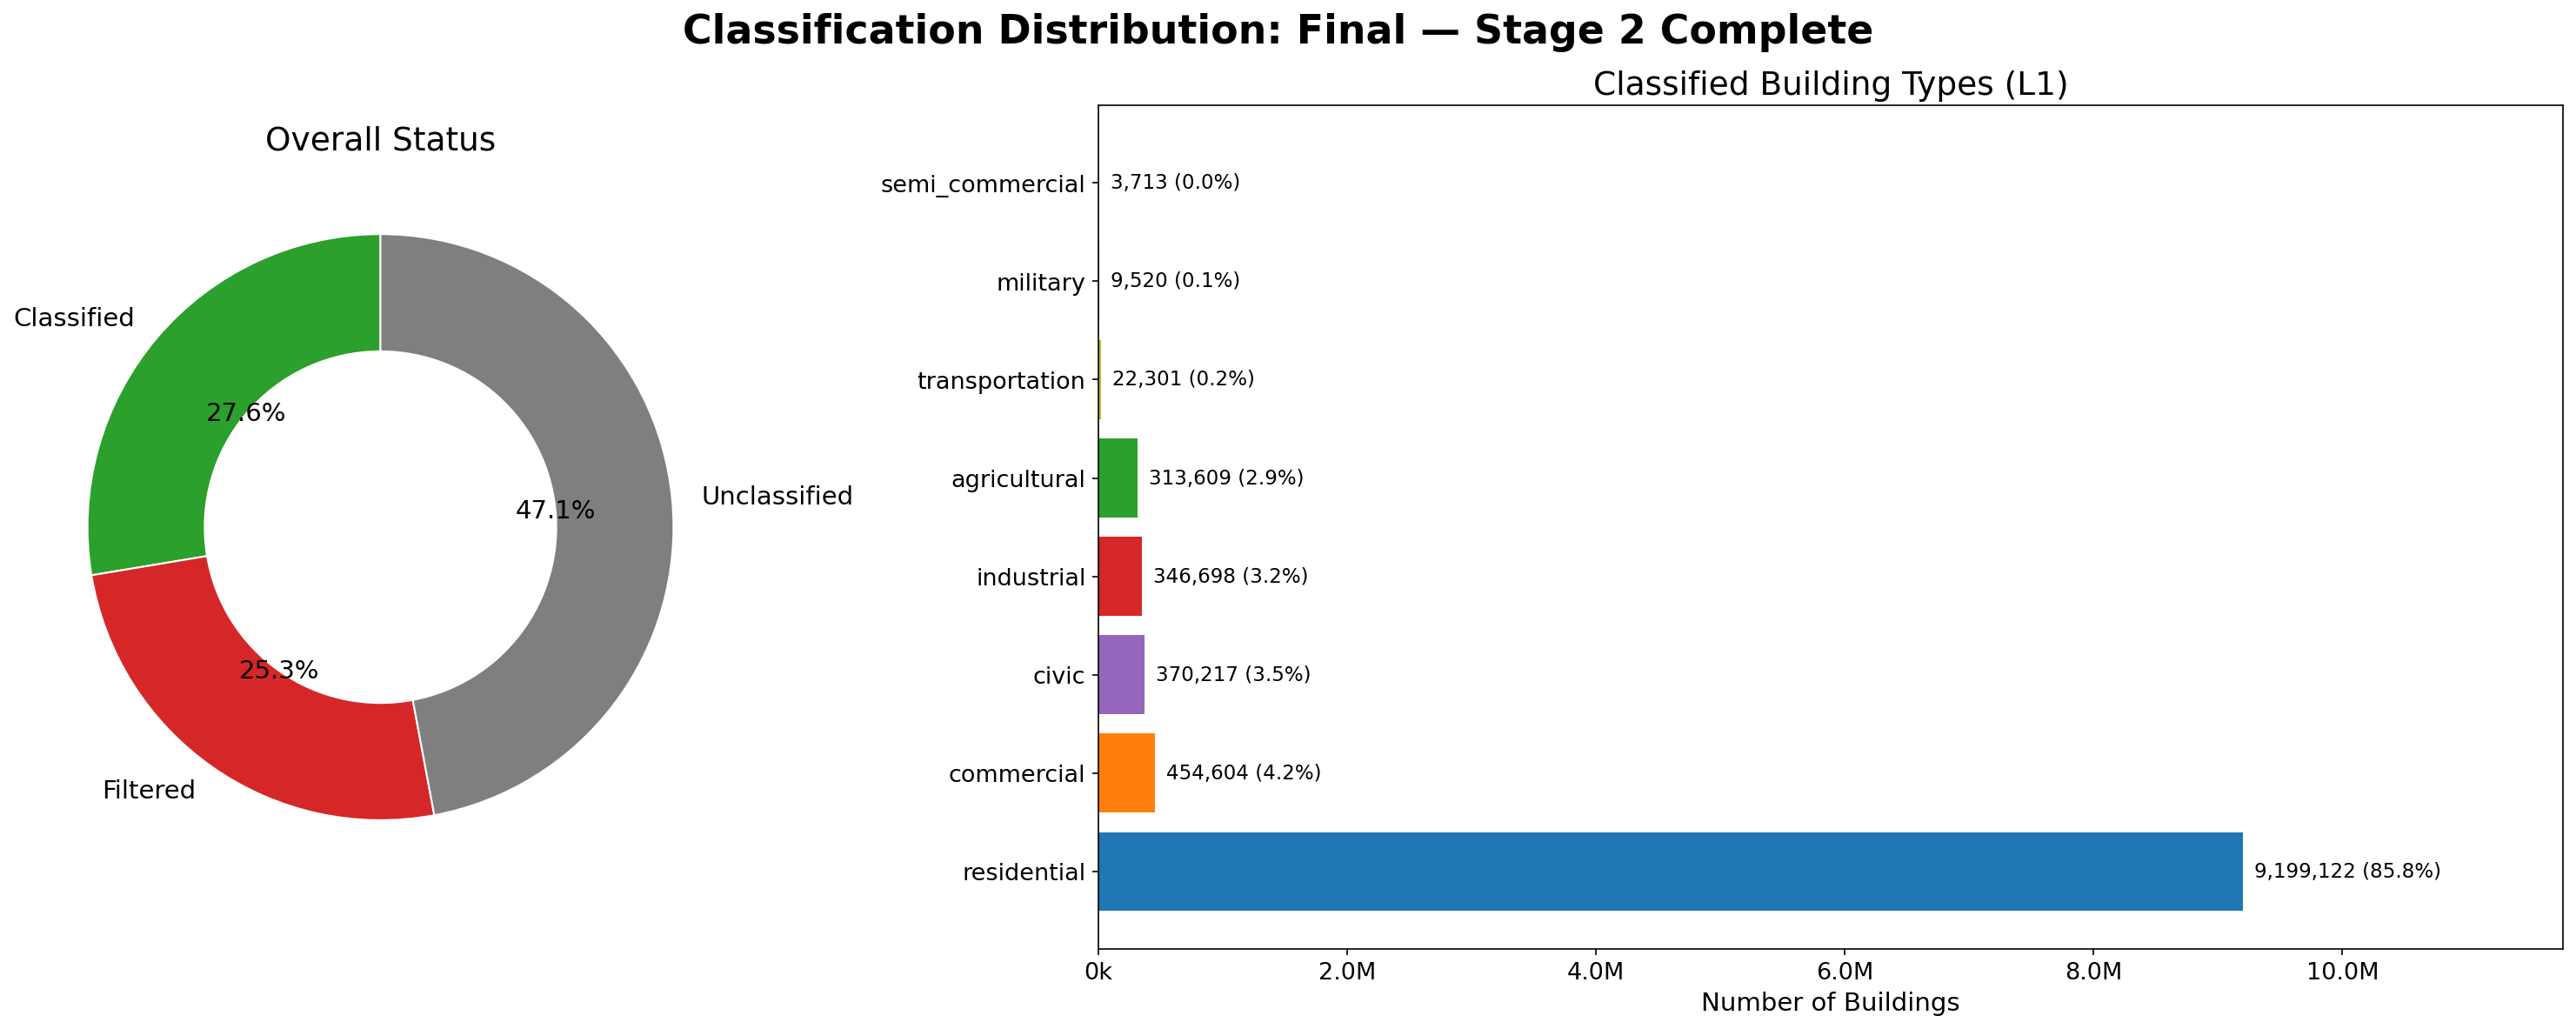

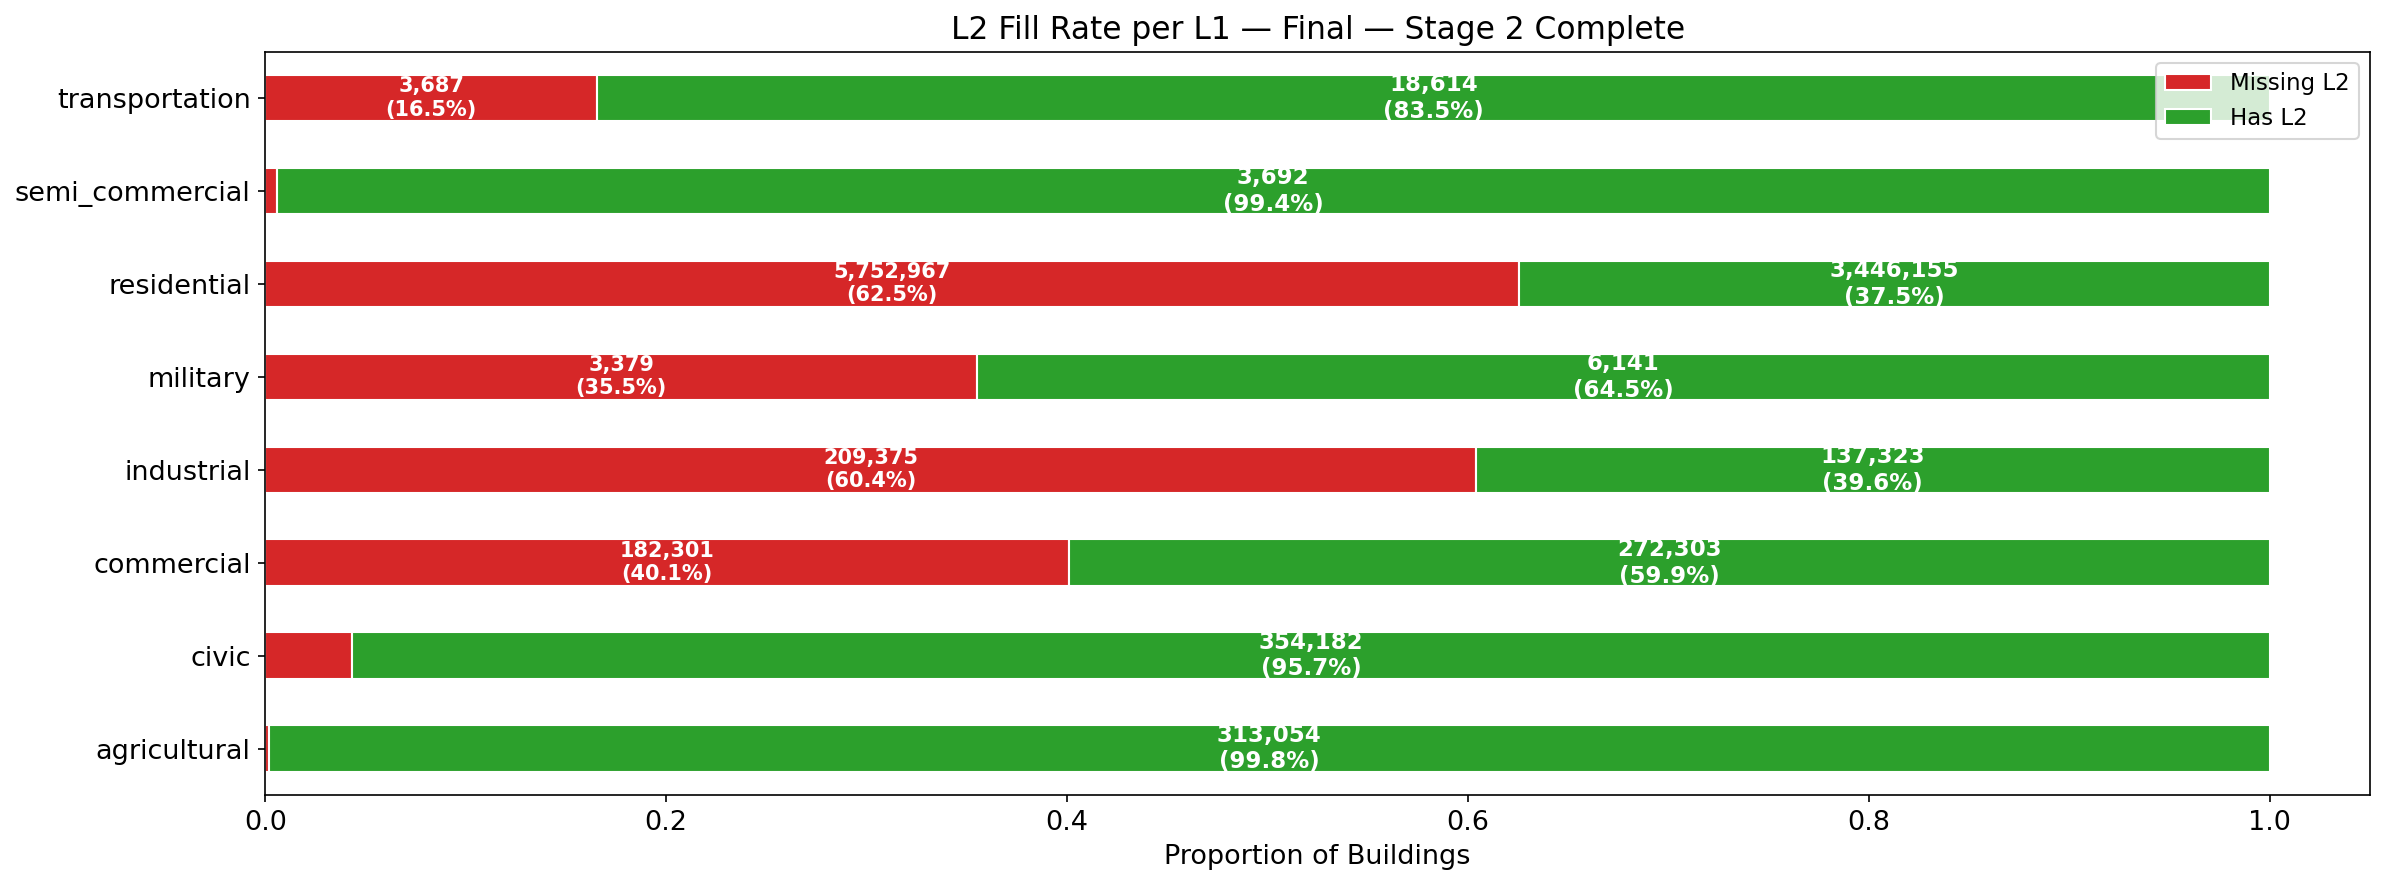


Classified by each rule:
stage2_source
rule1_small_area                          5627188
rule3_trusted_residential_zone            1433865
rule2_garage_filter                         74323
rule7_polygon_poi_contained_civic           58722
rule4_trusted_industrial_zone               44970
rule5_trusted_commercial_zone               29785
rule6_trusted_military_zone                  1232
rule7_polygon_poi_contained_commercial        362

Still unclassified (→ stage 3 ML): 18,259,833 (47.1%)


In [23]:
print("\n" + "="*55)
print("STAGE 2 COMPLETE — Final Summary")
print("="*55)
evaluate_step(gdf_bldg, "Final — Stage 2 Complete")

print("\nClassified by each rule:")
print(gdf_bldg['stage2_source'].value_counts(dropna=True).to_string())

still_unclassified = unclassified_mask(gdf_bldg).sum()
print(f"\nStill unclassified (→ stage 3 ML): {still_unclassified:,} "
      f"({still_unclassified/len(gdf_bldg):.1%})")

In [24]:
OUT_PATH = os.path.join(DATA_DIR, 'processed', 'germany_buildings_classified_stage2.parquet')
gdf_bldg.to_parquet(OUT_PATH, index=False)
print(f"\nSaved → {OUT_PATH}")
print(f"Columns: {list(gdf_bldg.columns)}")


Saved → /fast/home/o-olajuyigbe/osm_project/data/processed/germany_buildings_classified_stage2.parquet
Columns: ['id', 'geometry', 'building', 'tag_l1', 'tag_l2', 'is_abandoned', 'tag_is_mixed', 'tag_source', 'tag_used', 'all_candidates', 'addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'name', 'amenity', 'building:use', 'craft', 'office', 'shop', 'tags', 'building:levels', 'address_tier', 'area_sqm', 'perimeter_m', 'compactness', 'building_l1', 'building_l2', 'building_is_mixed', 'buse_l1', 'buse_l2', 'buse_is_mixed', 'amenity_l1', 'amenity_l2', 'shop_l1', 'shop_l2', 'stage1_l1', 'stage1_l2', 'stage1_is_mixed', 'stage1_source', 'raw_label', 'stage2_l1', 'stage2_l2', 'stage2_source', 'landuse_l1', 'landuse_l2', 'landuse_used', 'landuse_osm_id']
